In [ ]:


# ============================================================
# STEP 1: Environment setup + dataset loading + manuscript-ready
# descriptive statistics + troubleshooting diagnostics
# ============================================================

import os
import sys
import json
import time
import random
import hashlib
import warnings
import platform
import datetime
from pathlib import Path

import numpy as np
import pandas as pd

# Optional display settings for cleaner notebook outputs
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("=" * 80)
print("STEP 1: ENVIRONMENT + DATASET INSPECTION")
print("=" * 80)

print("\n[Environment]")
print("Python version      :", sys.version)
print("Platform            :", platform.platform())
print("NumPy version       :", np.__version__)
print("Pandas version      :", pd.__version__)
print("Random seed         :", RANDOM_SEED)

# -----------------------------
# User input: dataset path
# -----------------------------
DATA_PATH = "../datasets/ton-iot-train_test_network.csv"  

print("\n[Dataset path]")
print(DATA_PATH)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset file not found: {DATA_PATH}")

file_size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
print(f"File size           : {file_size_mb:.2f} MB")

# -----------------------------
# Safe dataset loading
# -----------------------------
t0 = time.perf_counter()

try:
    df = pd.read_csv(DATA_PATH, low_memory=False)
except UnicodeDecodeError:
    print("UTF-8 loading failed. Retrying with latin1 encoding...")
    df = pd.read_csv(DATA_PATH, low_memory=False, encoding="latin1")
except Exception as e:
    raise RuntimeError(f"Failed to load dataset: {e}")

load_time = time.perf_counter() - t0

print("\n[Load status]")
print(f"Dataset loaded successfully in {load_time:.4f} seconds")

# -----------------------------
# Basic shape and preview
# -----------------------------
print("\n[Basic dataset summary]")
print("Rows                :", df.shape[0])
print("Columns             :", df.shape[1])

print("\n[Column names]")
print(df.columns.tolist())

print("\n[First 5 rows]")
print(df.head())

print("\n[Last 5 rows]")
print(df.tail())

print("\n[Random 3 rows]")
print(df.sample(min(3, len(df)), random_state=RANDOM_SEED))

# -----------------------------
# Column-level metadata
# -----------------------------
print("\n[Column data types]")
dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "null_percent": (100 * df.isna().mean()).round(4).values,
    "n_unique": df.nunique(dropna=True).values
}).sort_values(by=["dtype", "null_percent", "n_unique"], ascending=[True, False, False])

print(dtype_df)

# -----------------------------
# Memory usage
# -----------------------------
mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print("\n[Memory usage]")
print(f"Approximate in-memory size: {mem_mb:.2f} MB")

# -----------------------------
# Missing values
# -----------------------------
print("\n[Missing values summary]")
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

if len(missing_counts) == 0:
    print("No missing values detected.")
else:
    missing_df = pd.DataFrame({
        "missing_count": missing_counts,
        "missing_percent": (100 * missing_counts / len(df)).round(4)
    })
    print(missing_df)

# -----------------------------
# Duplicate analysis
# -----------------------------
print("\n[Duplicate analysis]")
n_dup = df.duplicated().sum()
dup_pct = 100 * n_dup / len(df) if len(df) > 0 else 0
print("Duplicate rows      :", n_dup)
print(f"Duplicate percent   : {dup_pct:.4f}%")

# -----------------------------
# Numeric vs non-numeric columns
# -----------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n[Column type groups]")
print("Numeric columns     :", len(numeric_cols))
print("Non-numeric columns :", len(non_numeric_cols))

print("\nNumeric columns list:")
print(numeric_cols)

print("\nNon-numeric columns list:")
print(non_numeric_cols)


# -----------------------------
# Candidate label column detection
# -----------------------------
print("\n[Candidate label columns]")
candidate_keywords = ["label", "attack", "class", "category", "target", "type"]
candidate_label_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in candidate_keywords)
]
print(candidate_label_cols if candidate_label_cols else "No obvious label column found automatically.")

# For each candidate label column, print class distribution
for col in candidate_label_cols:
    print("\n" + "-" * 80)
    print(f"Candidate label column: {col}")
    print("dtype               :", df[col].dtype)
    print("unique classes      :", df[col].nunique(dropna=False))
    print("top class counts:")
    print(df[col].value_counts(dropna=False).head(20))
    print("class percentages (%):")
    print((100 * df[col].value_counts(dropna=False, normalize=True)).round(4).head(20))

# -----------------------------
# Low-cardinality non-numeric columns
# Useful for spotting label-like or protocol-like fields
# -----------------------------
print("\n[Low-cardinality non-numeric columns (<= 25 unique values)]")
low_card_non_num = []
for c in non_numeric_cols:
    nunq = df[c].nunique(dropna=False)
    if nunq <= 25:
        low_card_non_num.append(c)

if len(low_card_non_num) == 0:
    print("None found.")
else:
    for c in low_card_non_num:
        print("\nColumn:", c)
        print("Unique values:", df[c].nunique(dropna=False))
        print(df[c].value_counts(dropna=False).head(25))

# -----------------------------
# Potential identifier/high-cardinality columns
# Useful for leakage inspection
# -----------------------------
print("\n[Potential high-cardinality / identifier-like columns]")
high_card_df = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "unique_ratio": [df[c].nunique(dropna=True) / len(df) if len(df) > 0 else 0 for c in df.columns],
    "dtype": [str(df[c].dtype) for c in df.columns]
}).sort_values(by="unique_ratio", ascending=False)

print(high_card_df.head(30))

# -----------------------------
# Basic numeric descriptive stats
# -----------------------------
if len(numeric_cols) > 0:
    print("\n[Numeric descriptive statistics]")
    print(df[numeric_cols].describe().T)
else:
    print("\n[Numeric descriptive statistics]")
    print("No numeric columns found.")


# -----------------------------
# Infinite value check in numeric columns
# -----------------------------
print("\n[Infinite value check]")
if len(numeric_cols) > 0:
    inf_counts = np.isinf(df[numeric_cols].select_dtypes(include=[np.number])).sum()
    inf_counts = inf_counts[inf_counts > 0]
    if len(inf_counts) == 0:
        print("No +inf or -inf values detected in numeric columns.")
    else:
        print(inf_counts.sort_values(ascending=False))
else:
    print("Skipped because no numeric columns were detected.")

# -----------------------------
# Object/string columns: sample unique values
# Helps identify protocol/attack fields and dirty formatting
# -----------------------------
print("\n[Object/string columns: example values]")
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

if len(obj_cols) == 0:
    print("No object/string columns found.")
else:
    for c in obj_cols[:20]:   # keep output manageable
        vals = df[c].dropna().astype(str).unique()[:10]
        print(f"\nColumn: {c}")
        print("Example values:", vals)

# -----------------------------
# Suspicious columns that may cause leakage
# -----------------------------
print("\n[Potential leakage-related columns by name pattern]")
leakage_keywords = [
    "label", "attack", "class", "category", "target",
    "src", "dst", "ip", "addr", "port", "flow_id", "session",
    "timestamp", "time", "date", "ts", "uid", "id"
]

suspicious_cols = [c for c in df.columns if any(k in c.lower() for k in leakage_keywords)]
print(suspicious_cols if suspicious_cols else "No suspicious columns found by keyword rule.")

# -----------------------------
# Manuscript-ready dataset summary block
# -----------------------------
print("\n" + "=" * 80)
print("[MANUSCRIPT-READY DATASET SNAPSHOT]")
print("=" * 80)

summary = {
    "dataset_path": DATA_PATH,
    "loaded_at_utc": datetime.datetime.utcnow().isoformat() + "Z",
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "memory_mb": round(mem_mb, 4),
    "load_time_seconds": round(load_time, 4),
    "duplicate_rows": int(n_dup),
    "duplicate_percent": round(dup_pct, 4),
    "numeric_columns": len(numeric_cols),
    "non_numeric_columns": len(non_numeric_cols),
    "candidate_label_columns": candidate_label_cols,
    "columns_with_missing_values": int((df.isna().sum() > 0).sum())
}

print(json.dumps(summary, indent=2))


# -----------------------------
# Save quick profiling artifacts for later manuscript use
# -----------------------------
OUT_DIR = "dataset_inspection_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

dtype_df.to_csv(os.path.join(OUT_DIR, "column_profile.csv"), index=False)
high_card_df.to_csv(os.path.join(OUT_DIR, "high_cardinality_columns.csv"), index=False)

if len(missing_counts) > 0:
    missing_df.to_csv(os.path.join(OUT_DIR, "missing_value_summary.csv"))

with open(os.path.join(OUT_DIR, "dataset_snapshot_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\n[Artifacts saved]")
print(f"Saved profiling files to: {OUT_DIR}")

print("\nSTEP 1 completed successfully.")



STEP 1: ENVIRONMENT + DATASET INSPECTION

[Environment]
Python version      : 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:36:49) [MSC v.1944 64 bit (AMD64)]
Platform            : Windows-10-10.0.26200-SP0
NumPy version       : 2.2.6
Pandas version      : 2.3.3
Random seed         : 42

[Dataset path]
../datasets/ton-iot-train_test_network.csv
File size           : 28.52 MB

[Load status]
Dataset loaded successfully in 0.6744 seconds

[Basic dataset summary]
Rows                : 211043
Columns             : 44

[Column names]
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_requ

In [25]:
# ============================================================
# STEP 2: Multiclass target preparation + data cleaning +
# leakage-aware feature design + stratified train/val/test split
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=" * 80)
print("STEP 2: MULTICLASS TARGET PREPARATION + CLEANING + SPLITTING")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
assert "df" in globals(), "DataFrame 'df' not found. Run Step 1 first."
assert "type" in df.columns, "Expected multiclass target column 'type' not found."
assert "label" in df.columns, "Expected binary helper column 'label' not found."

df_work = df.copy()

print("\n[Initial dataset shape]")
print(df_work.shape)

# ------------------------------------------------------------------
# Standardize target text
# ------------------------------------------------------------------
df_work["type"] = df_work["type"].astype(str).str.strip().str.lower()
df_work["label"] = pd.to_numeric(df_work["label"], errors="coerce").fillna(-1).astype(int)

print("\n[Original multiclass distribution: 'type']")
print(df_work["type"].value_counts(dropna=False))

print("\n[Original binary distribution: 'label']")
print(df_work["label"].value_counts(dropna=False))

# ------------------------------------------------------------------
# Binary-vs-multiclass consistency check
# normal should correspond to label=0, attacks to label=1
# ------------------------------------------------------------------
print("\n[Consistency check between 'type' and binary 'label']")
consistency_table = pd.crosstab(df_work["type"], df_work["label"], margins=True)
print(consistency_table)

# ------------------------------------------------------------------
# Remove exact duplicate rows
# Manuscript-relevant because duplicates can inflate performance
# ------------------------------------------------------------------
n_before = len(df_work)
dup_count = df_work.duplicated().sum()

df_work = df_work.drop_duplicates().reset_index(drop=True)

n_after = len(df_work)
removed = n_before - n_after

print("\n[Duplicate handling]")
print("Rows before deduplication :", n_before)
print("Duplicate rows removed    :", removed)
print("Rows after deduplication  :", n_after)
print(f"Percent removed           : {100 * removed / max(n_before, 1):.4f}%")

print("\n[Class distribution after deduplication]")
print(df_work["type"].value_counts())

# ------------------------------------------------------------------
# Rare class handling
# First manuscript-grade run: exclude extremely small class 'mitm'
# so metrics are more stable. We can revisit later.
# ------------------------------------------------------------------
MIN_CLASS_COUNT = 2000

class_counts = df_work["type"].value_counts()
rare_classes = class_counts[class_counts < MIN_CLASS_COUNT].index.tolist()

print("\n[Rare class analysis]")
print("Minimum class count threshold:", MIN_CLASS_COUNT)
print("Rare classes detected        :", rare_classes if rare_classes else "None")

df_main = df_work[~df_work["type"].isin(rare_classes)].copy().reset_index(drop=True)

print("\n[Dataset shape after rare-class filtering]")
print(df_main.shape)

print("\n[Retained multiclass distribution]")
print(df_main["type"].value_counts())

excluded_summary = {
    "rare_classes_removed": rare_classes,
    "rows_removed_due_to_rare_classes": int(len(df_work) - len(df_main))
}
print("\n[Excluded class summary]")
print(json.dumps(excluded_summary, indent=2))

# ------------------------------------------------------------------
# Preserve context columns for forensic graph/evidence pipeline
# These are NOT all necessarily model features.
# ------------------------------------------------------------------
CONTEXT_COLS = [c for c in [
    "src_ip", "dst_ip", "src_port", "dst_port", "proto", "service", "conn_state"
] if c in df_main.columns]

print("\n[Context columns preserved for forensic use]")
print(CONTEXT_COLS)

# ------------------------------------------------------------------
# Define target and feature exclusions
# - 'type' is multiclass target
# - 'label' is binary helper and must be excluded from features
# - raw IPs are excluded from model features to reduce leakage / memorization
# ------------------------------------------------------------------
TARGET_COL = "type"
BINARY_HELPER_COL = "label"

DROP_FROM_FEATURES = [c for c in [
    TARGET_COL,
    BINARY_HELPER_COL,
    "src_ip",
    "dst_ip"
] if c in df_main.columns]

print("\n[Columns dropped from model features]")
print(DROP_FROM_FEATURES)

# ------------------------------------------------------------------
# Build feature table
# Replace '-' placeholders in object columns to make categorical handling explicit
# ------------------------------------------------------------------
X_raw = df_main.drop(columns=DROP_FROM_FEATURES, errors="ignore").copy()
y_text = df_main[TARGET_COL].copy()

# normalize placeholder tokens in object columns
obj_cols = X_raw.select_dtypes(include=["object", "string"]).columns.tolist()
for c in obj_cols:
    X_raw[c] = X_raw[c].astype(str).str.strip()
    X_raw[c] = X_raw[c].replace({"-": "MISSING_TOKEN", "": "MISSING_TOKEN", "nan": "MISSING_TOKEN"})

print("\n[Raw feature matrix]")
print("Shape:", X_raw.shape)

print("\n[Feature dtypes before encoding]")
print(X_raw.dtypes.value_counts())

# ------------------------------------------------------------------
# Encode multiclass target
# ------------------------------------------------------------------
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

label_mapping = {cls: int(idx) for idx, cls in enumerate(label_encoder.classes_)}
inv_label_mapping = {int(idx): cls for cls, idx in label_mapping.items()}

print("\n[Multiclass label mapping]")
print(label_mapping)

print("\n[Encoded target distribution]")
print(pd.Series(y).value_counts().sort_index())

# ------------------------------------------------------------------
# Column groups for modeling
# ------------------------------------------------------------------
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n[Model feature groups]")
print("Numeric feature count     :", len(numeric_cols))
print("Categorical feature count :", len(categorical_cols))

print("\nNumeric feature columns:")
print(numeric_cols)

print("\nCategorical feature columns:")
print(categorical_cols)

# ------------------------------------------------------------------
# Cardinality review of categorical columns
# Useful for deciding one-hot vs frequency encoding later
# ------------------------------------------------------------------
cat_cardinality = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [X_raw[c].nunique(dropna=False) for c in categorical_cols]
}).sort_values(by="n_unique", ascending=False)

print("\n[Categorical cardinality summary]")
print(cat_cardinality)

# ------------------------------------------------------------------
# Optional: identify very high-cardinality categorical columns
# We may frequency-encode these later instead of one-hot encoding
# ------------------------------------------------------------------
HIGH_CARD_THRESHOLD = 50
high_card_cat_cols = cat_cardinality.loc[
    cat_cardinality["n_unique"] > HIGH_CARD_THRESHOLD, "column"
].tolist()

low_mid_card_cat_cols = cat_cardinality.loc[
    cat_cardinality["n_unique"] <= HIGH_CARD_THRESHOLD, "column"
].tolist()

print("\n[Categorical encoding strategy suggestion]")
print("High-cardinality categorical columns  :", high_card_cat_cols if high_card_cat_cols else "None")
print("Low/mid-cardinality categorical cols  :", low_mid_card_cat_cols if low_mid_card_cat_cols else "None")

# ------------------------------------------------------------------
# Stratified split: train / val / test
# First stable setup for multiclass manuscript pipeline
# ------------------------------------------------------------------
X_trainval_raw, X_test_raw, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X_raw,
    y,
    df_main.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_raw, X_val_raw, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval_raw,
    y_trainval,
    idx_trainval,
    test_size=0.25,   # 0.25 of 0.80 = 0.20 overall
    random_state=42,
    stratify=y_trainval
)

# context frames aligned with split indices
ctx_train = df_main.loc[idx_train, CONTEXT_COLS].reset_index(drop=True)
ctx_val   = df_main.loc[idx_val, CONTEXT_COLS].reset_index(drop=True)
ctx_test  = df_main.loc[idx_test, CONTEXT_COLS].reset_index(drop=True)

# reset feature indices for cleaner downstream use
X_train_raw = X_train_raw.reset_index(drop=True)
X_val_raw   = X_val_raw.reset_index(drop=True)
X_test_raw  = X_test_raw.reset_index(drop=True)

y_train = pd.Series(y_train).reset_index(drop=True)
y_val   = pd.Series(y_val).reset_index(drop=True)
y_test  = pd.Series(y_test).reset_index(drop=True)

# ------------------------------------------------------------------
# Split diagnostics
# ------------------------------------------------------------------
print("\n[Split shapes]")
print("X_train_raw :", X_train_raw.shape)
print("X_val_raw   :", X_val_raw.shape)
print("X_test_raw  :", X_test_raw.shape)

def print_split_distribution(name, y_split):
    vc = pd.Series(y_split).value_counts().sort_index()
    pct = pd.Series(y_split).value_counts(normalize=True).sort_index() * 100
    df_dist = pd.DataFrame({
        "class_id": vc.index,
        "class_name": [inv_label_mapping[i] for i in vc.index],
        "count": vc.values,
        "percent": pct.values.round(4)
    })
    print(f"\n[{name} class distribution]")
    print(df_dist)

print_split_distribution("TRAIN", y_train)
print_split_distribution("VAL", y_val)
print_split_distribution("TEST", y_test)

# ------------------------------------------------------------------
# Check for unseen categorical levels between splits
# Important for robust preprocessing
# ------------------------------------------------------------------
print("\n[Unseen-category diagnostic: validation/test vs training]")
unseen_report = []

for c in categorical_cols:
    train_vals = set(X_train_raw[c].astype(str).unique())
    val_vals = set(X_val_raw[c].astype(str).unique())
    test_vals = set(X_test_raw[c].astype(str).unique())

    unseen_val = sorted(list(val_vals - train_vals))
    unseen_test = sorted(list(test_vals - train_vals))

    unseen_report.append({
        "column": c,
        "n_train_unique": len(train_vals),
        "n_val_unseen": len(unseen_val),
        "n_test_unseen": len(unseen_test)
    })

unseen_report_df = pd.DataFrame(unseen_report).sort_values(
    by=["n_test_unseen", "n_val_unseen", "n_train_unique"],
    ascending=[False, False, False]
)

print(unseen_report_df)

# ------------------------------------------------------------------
# Save split and metadata artifacts
# ------------------------------------------------------------------
OUT_DIR = "multiclass_preparation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

cat_cardinality.to_csv(os.path.join(OUT_DIR, "categorical_cardinality.csv"), index=False)
unseen_report_df.to_csv(os.path.join(OUT_DIR, "unseen_category_report.csv"), index=False)

prep_summary = {
    "target_column": TARGET_COL,
    "binary_helper_column": BINARY_HELPER_COL,
    "label_mapping": label_mapping,
    "rare_classes_removed": rare_classes,
    "rows_after_deduplication": int(len(df_work)),
    "rows_after_rare_class_filter": int(len(df_main)),
    "n_features_raw": int(X_raw.shape[1]),
    "numeric_feature_count": int(len(numeric_cols)),
    "categorical_feature_count": int(len(categorical_cols)),
    "high_cardinality_categorical_columns": high_card_cat_cols,
    "context_columns": CONTEXT_COLS,
    "train_shape": list(X_train_raw.shape),
    "val_shape": list(X_val_raw.shape),
    "test_shape": list(X_test_raw.shape)
}

with open(os.path.join(OUT_DIR, "multiclass_prep_summary.json"), "w", encoding="utf-8") as f:
    json.dump(prep_summary, f, indent=2)

t_step2 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Preparation summary]")
print(json.dumps(prep_summary, indent=2))

print(f"\nSTEP 2 completed successfully in {t_step2:.4f} seconds.")

STEP 2: MULTICLASS TARGET PREPARATION + CLEANING + SPLITTING

[Initial dataset shape]
(211043, 44)

[Original multiclass distribution: 'type']
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

[Original binary distribution: 'label']
label
1    161043
0     50000
Name: count, dtype: int64

[Consistency check between 'type' and binary 'label']
label           0       1     All
type                             
backdoor        0   20000   20000
ddos            0   20000   20000
dos             0   20000   20000
injection       0   20000   20000
mitm            0    1043    1043
normal      50000       0   50000
password        0   20000   20000
ransomware      0   20000   20000
scanning        0   20000   20000
xss             0   20000   20000
All         50000  161043  211043

[Duplicate handling]
Rows befor

In [27]:
# ============================================================
# STEP 3: Multiclass preprocessing + baseline training +
# validation-based model selection (manuscript-ready)
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("=" * 80)
print("STEP 3: MULTICLASS PREPROCESSING + TRAINING + MODEL SELECTION")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = [
    "X_train_raw", "X_val_raw", "X_test_raw",
    "y_train", "y_val", "y_test",
    "numeric_cols", "categorical_cols",
    "high_card_cat_cols", "low_mid_card_cat_cols",
    "inv_label_mapping", "label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 2 first."

# ------------------------------------------------------------------
# Custom frequency encoder for high-cardinality categorical columns
# Learned on training only, safe on unseen values
# ------------------------------------------------------------------
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps_ = {}
        self.columns_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.freq_maps_ = {}

        n = len(X)
        for c in self.columns_:
            s = X[c].astype(str)
            vc = s.value_counts(dropna=False)
            self.freq_maps_[c] = (vc / max(n, 1)).to_dict()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), len(self.columns_)), dtype=float)

        for j, c in enumerate(self.columns_):
            fmap = self.freq_maps_.get(c, {})
            out[:, j] = X[c].astype(str).map(fmap).fillna(0.0).astype(float).to_numpy()

        return out

# ------------------------------------------------------------------
# Optional log transform for highly skewed numeric traffic features
# log1p is manuscript-friendly and often stabilizes variance
# ------------------------------------------------------------------
log_transform_candidates = [
    "duration", "src_bytes", "dst_bytes", "missed_bytes",
    "src_pkts", "src_ip_bytes", "dst_pkts", "dst_ip_bytes",
    "http_request_body_len", "http_response_body_len"
]
log_transform_numeric_cols = [c for c in log_transform_candidates if c in numeric_cols]
non_log_numeric_cols = [c for c in numeric_cols if c not in log_transform_numeric_cols]

print("\n[Numeric preprocessing plan]")
print("Log-transform numeric columns:")
print(log_transform_numeric_cols if log_transform_numeric_cols else "None")

print("\nNon-log numeric columns:")
print(non_log_numeric_cols if non_log_numeric_cols else "None")

print("\n[Categorical preprocessing plan]")
print("High-cardinality categorical columns:")
print(high_card_cat_cols if high_card_cat_cols else "None")

print("\nLow/mid-cardinality categorical columns:")
print(low_mid_card_cat_cols if low_mid_card_cat_cols else "None")

# ------------------------------------------------------------------
# Build preprocessing pipelines
# We create two preprocessors:
#   1) scaled_preprocessor  -> for logistic regression
#   2) tree_preprocessor    -> for tree-based models
# ------------------------------------------------------------------

# numeric branches
log_num_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

plain_num_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

log_num_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False))
])

plain_num_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# low/mid categorical one-hot
ohe_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# high-cardinality categorical frequency encoding
freq_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq", FrequencyEncoder())
])

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_num_pipe_scaled, log_transform_numeric_cols),
        ("plain_num", plain_num_pipe_scaled, non_log_numeric_cols),
        ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols),
        ("high_cat", freq_pipe, high_card_cat_cols),
    ],
    remainder="drop"
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_num_pipe_tree, log_transform_numeric_cols),
        ("plain_num", plain_num_pipe_tree, non_log_numeric_cols),
        ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols),
        ("high_cat", freq_pipe, high_card_cat_cols),
    ],
    remainder="drop"
)

# ------------------------------------------------------------------
# Define models
# ------------------------------------------------------------------
models = {
    "logreg": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("clf", LogisticRegression(
            max_iter=400,
            multi_class="auto",
            class_weight="balanced",
            n_jobs=None
        ))
    ]),
    "rf": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "extratrees": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", ExtraTreesClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])
}

print("\n[Candidate models]")
print(list(models.keys()))

# ------------------------------------------------------------------
# Evaluation helper for multiclass validation
# ------------------------------------------------------------------
def evaluate_multiclass_model(model, X_tr, y_tr, X_va, y_va):
    result = {}

    # fit time
    t_fit0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_s = time.perf_counter() - t_fit0

    # predict time
    t_pred0 = time.perf_counter()
    y_pred = model.predict(X_va)
    pred_s = time.perf_counter() - t_pred0

    # metrics
    acc = accuracy_score(y_va, y_pred)
    f1_macro = f1_score(y_va, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_va, y_pred, average="weighted", zero_division=0)
    prec_macro = precision_score(y_va, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_va, y_pred, average="macro", zero_division=0)

    result["val_acc"] = acc
    result["val_f1_macro"] = f1_macro
    result["val_f1_weighted"] = f1_weighted
    result["val_prec_macro"] = prec_macro
    result["val_rec_macro"] = rec_macro
    result["fit_s"] = fit_s
    result["pred_s"] = pred_s
    result["pred_ms_per_sample"] = 1000 * pred_s / len(X_va)

    # multiclass ROC-AUC (OVR macro) if predict_proba exists
    result["val_roc_auc_ovr_macro"] = np.nan
    result["val_roc_auc_ovr_weighted"] = np.nan
    result["y_pred"] = y_pred
    result["y_proba"] = None

    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X_va)
            result["y_proba"] = y_proba
            result["val_roc_auc_ovr_macro"] = roc_auc_score(
                y_va, y_proba, multi_class="ovr", average="macro"
            )
            result["val_roc_auc_ovr_weighted"] = roc_auc_score(
                y_va, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception as e:
            print(f"ROC-AUC computation warning: {e}")

    return result

# ------------------------------------------------------------------
# Train/evaluate all candidate models on validation split
# ------------------------------------------------------------------
rows = []
val_diagnostics = {}

for name, model in models.items():
    print("\n" + "-" * 80)
    print(f"Training model: {name}")

    res = evaluate_multiclass_model(model, X_train_raw, y_train, X_val_raw, y_val)
    val_diagnostics[name] = res

    rows.append({
        "model": name,
        "val_acc": res["val_acc"],
        "val_f1_macro": res["val_f1_macro"],
        "val_f1_weighted": res["val_f1_weighted"],
        "val_prec_macro": res["val_prec_macro"],
        "val_rec_macro": res["val_rec_macro"],
        "val_roc_auc_ovr_macro": res["val_roc_auc_ovr_macro"],
        "val_roc_auc_ovr_weighted": res["val_roc_auc_ovr_weighted"],
        "fit_s": res["fit_s"],
        "pred_s": res["pred_s"],
        "pred_ms_per_sample": res["pred_ms_per_sample"]
    })

    print(f"Validation Accuracy              : {res['val_acc']:.6f}")
    print(f"Validation F1 Macro              : {res['val_f1_macro']:.6f}")
    print(f"Validation F1 Weighted           : {res['val_f1_weighted']:.6f}")
    print(f"Validation Precision Macro       : {res['val_prec_macro']:.6f}")
    print(f"Validation Recall Macro          : {res['val_rec_macro']:.6f}")
    print(f"Validation ROC-AUC OVR Macro     : {res['val_roc_auc_ovr_macro']:.6f}")
    print(f"Validation ROC-AUC OVR Weighted  : {res['val_roc_auc_ovr_weighted']:.6f}")
    print(f"Fit time (s)                     : {res['fit_s']:.4f}")
    print(f"Predict time (s)                 : {res['pred_s']:.4f}")
    print(f"Predict ms/sample                : {res['pred_ms_per_sample']:.6f}")

# ------------------------------------------------------------------
# Model comparison table
# Sort primarily by macro-F1 for balanced multiclass quality
# ------------------------------------------------------------------
scores_df = pd.DataFrame(rows).sort_values(
    by=["val_f1_macro", "val_f1_weighted", "val_roc_auc_ovr_macro", "pred_ms_per_sample"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("\n" + "=" * 80)
print("[VALIDATION MODEL COMPARISON TABLE]")
print("=" * 80)
print(scores_df)

# ------------------------------------------------------------------
# Select best model
# ------------------------------------------------------------------
best_name = scores_df.loc[0, "model"]
best_model = clone(models[best_name])

print("\n[Selected best model]")
print("Best model name:", best_name)

# ------------------------------------------------------------------
# Refit best model on TRAIN + VAL
# This is the model we will use for test evaluation in Step 4
# ------------------------------------------------------------------
X_trainval_raw = pd.concat([X_train_raw, X_val_raw], axis=0).reset_index(drop=True)
y_trainval = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)

t_refit0 = time.perf_counter()
best_model.fit(X_trainval_raw, y_trainval)
t_refit = time.perf_counter() - t_refit0

print("\n[Best model refit on TRAIN+VAL]")
print(f"Refit time (s): {t_refit:.4f}")

# ------------------------------------------------------------------
# Also fit all final models on TRAIN+VAL for later test comparison
# ------------------------------------------------------------------
final_models = {}
for name, model in models.items():
    m = clone(model)
    print(f"Fitting final model on TRAIN+VAL: {name}")
    m.fit(X_trainval_raw, y_trainval)
    final_models[name] = m

print("\nFinal models trained:")
print(list(final_models.keys()))

# ------------------------------------------------------------------
# Detailed classification report for validation best model
# Useful for manuscript interpretation before test stage
# ------------------------------------------------------------------
best_val_pred = val_diagnostics[best_name]["y_pred"]

print("\n" + "=" * 80)
print(f"[VALIDATION CLASSIFICATION REPORT: {best_name}]")
print("=" * 80)
print(classification_report(
    y_val,
    best_val_pred,
    target_names=[inv_label_mapping[i] for i in sorted(inv_label_mapping.keys())],
    digits=4,
    zero_division=0
))

# ------------------------------------------------------------------
# Validation confusion matrix
# ------------------------------------------------------------------
cm_val = confusion_matrix(y_val, best_val_pred, labels=sorted(inv_label_mapping.keys()))
cm_val_df = pd.DataFrame(
    cm_val,
    index=[f"true_{inv_label_mapping[i]}" for i in sorted(inv_label_mapping.keys())],
    columns=[f"pred_{inv_label_mapping[i]}" for i in sorted(inv_label_mapping.keys())]
)

print("\n[Validation confusion matrix]")
print(cm_val_df)

# ------------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------------
OUT_DIR = "multiclass_model_selection_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

scores_df.to_csv(os.path.join(OUT_DIR, "validation_model_comparison.csv"), index=False)
cm_val_df.to_csv(os.path.join(OUT_DIR, f"validation_confusion_matrix_{best_name}.csv"))

step3_summary = {
    "candidate_models": list(models.keys()),
    "best_model": best_name,
    "selection_rule": [
        "highest validation macro F1",
        "then highest validation weighted F1",
        "then highest validation OVR macro ROC-AUC",
        "then lowest latency"
    ],
    "refit_time_seconds": float(t_refit),
    "train_shape": list(X_train_raw.shape),
    "val_shape": list(X_val_raw.shape),
    "trainval_shape": list(X_trainval_raw.shape),
    "test_shape": list(X_test_raw.shape)
}

with open(os.path.join(OUT_DIR, "step3_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step3_summary, f, indent=2)

t_step3 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 3 summary]")
print(json.dumps(step3_summary, indent=2))

print(f"\nSTEP 3 completed successfully in {t_step3:.4f} seconds.")

STEP 3: MULTICLASS PREPROCESSING + TRAINING + MODEL SELECTION

[Numeric preprocessing plan]
Log-transform numeric columns:
['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_request_body_len', 'http_response_body_len']

Non-log numeric columns:
['src_port', 'dst_port', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_status_code']

[Categorical preprocessing plan]
High-cardinality categorical columns:
['dns_query', 'http_uri']

Low/mid-cardinality categorical columns:
['http_user_agent', 'conn_state', 'weird_name', 'http_trans_depth', 'http_resp_mime_types', 'service', 'ssl_subject', 'ssl_cipher', 'ssl_issuer', 'http_method', 'ssl_version', 'proto', 'dns_RD', 'dns_AA', 'dns_rejected', 'dns_RA', 'ssl_resumed', 'ssl_established', 'weird_addl', 'http_orig_mime_types', 'http_version', 'weird_notice']

[Candidate models]
['logreg', 'rf', 'extratrees']

-----------------------------------------------------------------------------

In [28]:
# ============================================================
# STEP 4: Multiclass test evaluation + comparison of final models
# + manuscript-ready summary tables
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    top_k_accuracy_score
)

print("=" * 80)
print("STEP 4: MULTICLASS TEST EVALUATION + FINAL MODEL COMPARISON")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = [
    "best_name", "best_model", "final_models",
    "X_test_raw", "y_test", "inv_label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 3 first."

class_ids = sorted(inv_label_mapping.keys())
class_names = [inv_label_mapping[i] for i in class_ids]

print("\n[Best model entering test evaluation]")
print("Best model name:", best_name)

print("\n[Test set shape]")
print(X_test_raw.shape)

print("\n[Test class names]")
print(class_names)

# ------------------------------------------------------------------
# Helper: evaluate a multiclass model on test
# ------------------------------------------------------------------
def evaluate_multiclass_test(model, X, y, class_ids):
    result = {}

    # predict labels
    t_pred0 = time.perf_counter()
    y_pred = model.predict(X)
    pred_s = time.perf_counter() - t_pred0

    result["y_pred"] = y_pred
    result["pred_time_s"] = pred_s
    result["pred_ms_per_sample"] = 1000 * pred_s / len(X)

    # basic metrics
    result["test_acc"] = accuracy_score(y, y_pred)
    result["test_f1_macro"] = f1_score(y, y_pred, average="macro", zero_division=0)
    result["test_f1_weighted"] = f1_score(y, y_pred, average="weighted", zero_division=0)
    result["test_prec_macro"] = precision_score(y, y_pred, average="macro", zero_division=0)
    result["test_rec_macro"] = recall_score(y, y_pred, average="macro", zero_division=0)

    # confusion matrix
    result["cm"] = confusion_matrix(y, y_pred, labels=class_ids)

    # predict probabilities if available
    result["y_proba"] = None
    result["proba_time_s"] = np.nan
    result["proba_ms_per_sample"] = np.nan
    result["test_roc_auc_ovr_macro"] = np.nan
    result["test_roc_auc_ovr_weighted"] = np.nan
    result["top2_acc"] = np.nan
    result["top3_acc"] = np.nan

    if hasattr(model, "predict_proba"):
        try:
            t_proba0 = time.perf_counter()
            y_proba = model.predict_proba(X)
            proba_s = time.perf_counter() - t_proba0

            result["y_proba"] = y_proba
            result["proba_time_s"] = proba_s
            result["proba_ms_per_sample"] = 1000 * proba_s / len(X)

            result["test_roc_auc_ovr_macro"] = roc_auc_score(
                y, y_proba, multi_class="ovr", average="macro"
            )
            result["test_roc_auc_ovr_weighted"] = roc_auc_score(
                y, y_proba, multi_class="ovr", average="weighted"
            )

            result["top2_acc"] = top_k_accuracy_score(y, y_proba, k=2, labels=class_ids)
            result["top3_acc"] = top_k_accuracy_score(y, y_proba, k=3, labels=class_ids)

        except Exception as e:
            print(f"Probability-based metric warning: {e}")

    return result

# ------------------------------------------------------------------
# Evaluate best model on test
# ------------------------------------------------------------------
best_test_res = evaluate_multiclass_test(best_model, X_test_raw, y_test, class_ids)

print("\n" + "=" * 80)
print(f"[TEST RESULTS: BEST MODEL = {best_name}]")
print("=" * 80)
print(f"Test Accuracy                 : {best_test_res['test_acc']:.6f}")
print(f"Test F1 Macro                 : {best_test_res['test_f1_macro']:.6f}")
print(f"Test F1 Weighted              : {best_test_res['test_f1_weighted']:.6f}")
print(f"Test Precision Macro          : {best_test_res['test_prec_macro']:.6f}")
print(f"Test Recall Macro             : {best_test_res['test_rec_macro']:.6f}")
print(f"Test ROC-AUC OVR Macro        : {best_test_res['test_roc_auc_ovr_macro']:.6f}")
print(f"Test ROC-AUC OVR Weighted     : {best_test_res['test_roc_auc_ovr_weighted']:.6f}")
print(f"Top-2 Accuracy                : {best_test_res['top2_acc']:.6f}")
print(f"Top-3 Accuracy                : {best_test_res['top3_acc']:.6f}")
print(f"Predict time total (s)        : {best_test_res['pred_time_s']:.6f}")
print(f"Predict latency (ms/sample)   : {best_test_res['pred_ms_per_sample']:.6f}")
print(f"Predict_proba total (s)       : {best_test_res['proba_time_s']:.6f}")
print(f"Predict_proba (ms/sample)     : {best_test_res['proba_ms_per_sample']:.6f}")

# ------------------------------------------------------------------
# Best model classification report
# ------------------------------------------------------------------
print("\n" + "=" * 80)
print(f"[TEST CLASSIFICATION REPORT: {best_name}]")
print("=" * 80)
print(classification_report(
    y_test,
    best_test_res["y_pred"],
    target_names=class_names,
    digits=4,
    zero_division=0
))

# ------------------------------------------------------------------
# Best model confusion matrix
# ------------------------------------------------------------------
cm_test = best_test_res["cm"]
cm_test_df = pd.DataFrame(
    cm_test,
    index=[f"true_{name}" for name in class_names],
    columns=[f"pred_{name}" for name in class_names]
)

print("\n[Best model test confusion matrix]")
print(cm_test_df)

# ------------------------------------------------------------------
# Per-class metrics table for manuscript use
# ------------------------------------------------------------------
report_dict = classification_report(
    y_test,
    best_test_res["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_rows = []
for cname in class_names:
    per_class_rows.append({
        "class_name": cname,
        "precision": report_dict[cname]["precision"],
        "recall": report_dict[cname]["recall"],
        "f1_score": report_dict[cname]["f1-score"],
        "support": report_dict[cname]["support"]
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values(by="f1_score", ascending=False).reset_index(drop=True)

print("\n[Per-class performance table]")
print(per_class_df)

# ------------------------------------------------------------------
# Compare all final models on test
# ------------------------------------------------------------------
compare_rows = []

for name, model in final_models.items():
    print(f"\nEvaluating final model on test: {name}")
    res = evaluate_multiclass_test(model, X_test_raw, y_test, class_ids)

    compare_rows.append({
        "model": name,
        "test_acc": res["test_acc"],
        "test_f1_macro": res["test_f1_macro"],
        "test_f1_weighted": res["test_f1_weighted"],
        "test_prec_macro": res["test_prec_macro"],
        "test_rec_macro": res["test_rec_macro"],
        "test_roc_auc_ovr_macro": res["test_roc_auc_ovr_macro"],
        "test_roc_auc_ovr_weighted": res["test_roc_auc_ovr_weighted"],
        "top2_acc": res["top2_acc"],
        "top3_acc": res["top3_acc"],
        "pred_time_s": res["pred_time_s"],
        "pred_ms_per_sample": res["pred_ms_per_sample"],
        "proba_time_s": res["proba_time_s"],
        "proba_ms_per_sample": res["proba_ms_per_sample"]
    })

compare_test_df = pd.DataFrame(compare_rows).sort_values(
    by=["test_f1_macro", "test_f1_weighted", "test_roc_auc_ovr_macro", "pred_ms_per_sample"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("\n" + "=" * 80)
print("[TEST MODEL COMPARISON TABLE]")
print("=" * 80)
print(compare_test_df)

# ------------------------------------------------------------------
# Macro vs weighted summary for manuscript discussion
# ------------------------------------------------------------------
summary_table = compare_test_df[[
    "model",
    "test_acc",
    "test_f1_macro",
    "test_f1_weighted",
    "test_roc_auc_ovr_macro",
    "pred_ms_per_sample"
]].copy()

print("\n[Compact manuscript-ready summary table]")
print(summary_table)

# ------------------------------------------------------------------
# Hardest classes analysis: sort by lowest per-class F1
# ------------------------------------------------------------------
hardest_classes_df = per_class_df.sort_values(by="f1_score", ascending=True).reset_index(drop=True)

print("\n[Hardest classes by F1]")
print(hardest_classes_df)

# ------------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------------
OUT_DIR = "multiclass_test_evaluation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

cm_test_df.to_csv(os.path.join(OUT_DIR, f"test_confusion_matrix_{best_name}.csv"))
per_class_df.to_csv(os.path.join(OUT_DIR, f"test_per_class_metrics_{best_name}.csv"), index=False)
compare_test_df.to_csv(os.path.join(OUT_DIR, "test_model_comparison.csv"), index=False)
summary_table.to_csv(os.path.join(OUT_DIR, "test_summary_table.csv"), index=False)
hardest_classes_df.to_csv(os.path.join(OUT_DIR, f"hardest_classes_{best_name}.csv"), index=False)

step4_summary = {
    "best_model": best_name,
    "test_shape": list(X_test_raw.shape),
    "class_names": class_names,
    "best_model_test_metrics": {
        "accuracy": float(best_test_res["test_acc"]),
        "f1_macro": float(best_test_res["test_f1_macro"]),
        "f1_weighted": float(best_test_res["test_f1_weighted"]),
        "precision_macro": float(best_test_res["test_prec_macro"]),
        "recall_macro": float(best_test_res["test_rec_macro"]),
        "roc_auc_ovr_macro": float(best_test_res["test_roc_auc_ovr_macro"]),
        "roc_auc_ovr_weighted": float(best_test_res["test_roc_auc_ovr_weighted"]),
        "top2_accuracy": float(best_test_res["top2_acc"]),
        "top3_accuracy": float(best_test_res["top3_acc"]),
        "pred_ms_per_sample": float(best_test_res["pred_ms_per_sample"]),
        "proba_ms_per_sample": float(best_test_res["proba_ms_per_sample"])
    }
}

with open(os.path.join(OUT_DIR, "step4_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step4_summary, f, indent=2)

t_step4 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 4 summary]")
print(json.dumps(step4_summary, indent=2))

print(f"\nSTEP 4 completed successfully in {t_step4:.4f} seconds.")

STEP 4: MULTICLASS TEST EVALUATION + FINAL MODEL COMPARISON

[Best model entering test evaluation]
Best model name: rf

[Test set shape]
(37887, 40)

[Test class names]
['backdoor', 'ddos', 'dos', 'injection', 'normal', 'password', 'ransomware', 'scanning', 'xss']

[TEST RESULTS: BEST MODEL = rf]
Test Accuracy                 : 0.990445
Test F1 Macro                 : 0.989228
Test F1 Weighted              : 0.990450
Test Precision Macro          : 0.989089
Test Recall Macro             : 0.989388
Test ROC-AUC OVR Macro        : 0.999552
Test ROC-AUC OVR Weighted     : 0.999590
Top-2 Accuracy                : 0.997176
Top-3 Accuracy                : 0.999076
Predict time total (s)        : 0.536316
Predict latency (ms/sample)   : 0.014156
Predict_proba total (s)       : 0.470938
Predict_proba (ms/sample)     : 0.012430

[TEST CLASSIFICATION REPORT: rf]
              precision    recall  f1-score   support

    backdoor     1.0000    0.9997    0.9999      3742
        ddos     0.9902   

STEP 5A: MULTICLASS GLOBAL EXPLAINABILITY

[Best model for XAI]
Model: rf

[Recovered transformed feature space]
Number of transformed features: 154
First 50 transformed feature names:
['duration__log1p', 'src_bytes__log1p', 'dst_bytes__log1p', 'missed_bytes__log1p', 'src_pkts__log1p', 'src_ip_bytes__log1p', 'dst_pkts__log1p', 'dst_ip_bytes__log1p', 'http_request_body_len__log1p', 'http_response_body_len__log1p', 'src_port__scaled', 'dst_port__scaled', 'dns_qclass__scaled', 'dns_qtype__scaled', 'dns_rcode__scaled', 'http_status_code__scaled', 'http_user_agent_Comos/0.9_(robot@xyleme.com)', 'http_user_agent_DAFUPnP', 'http_user_agent_DataCha0s/2.0', 'http_user_agent_Debian APT-HTTP/1.3 (1.7.4)', 'http_user_agent_MICROSOFT_DEVICE_METADATA_RETRIEVAL_CLIENT', 'http_user_agent_MISSING_TOKEN', 'http_user_agent_Microsoft BITS/7.8', 'http_user_agent_Microsoft NCSI', 'http_user_agent_Microsoft-CryptoAPI/10.0', 'http_user_agent_Microsoft-Delivery-Optimization/10.0', 'http_user_agent_Microsoft-WN

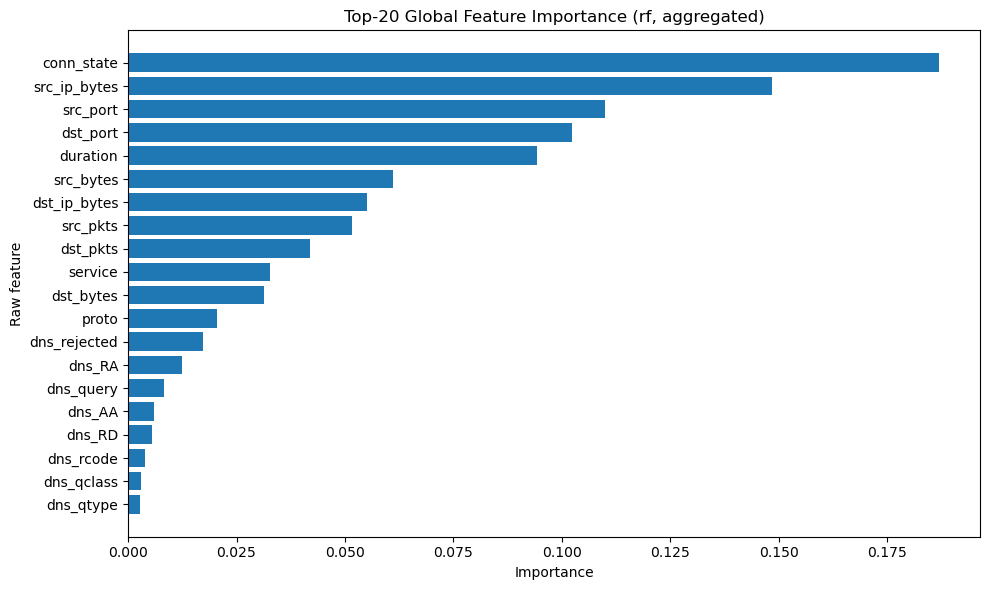

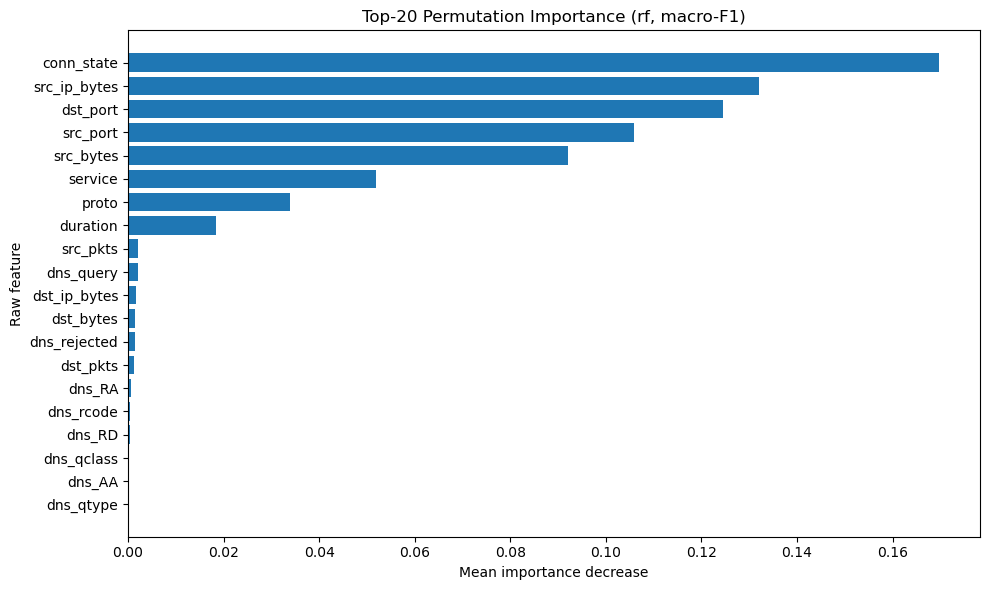


[Top 25 consensus-important raw features]
        raw_feature  importance  perm_importance_mean  perm_importance_std  builtin_rank  perm_rank  rank_sum
0        conn_state    0.186993              0.169790             0.003575           1.0        1.0       2.0
1      src_ip_bytes    0.148401              0.132073             0.001188           2.0        2.0       4.0
2          src_port    0.109874              0.105845             0.001665           3.0        4.0       7.0
3          dst_port    0.102404              0.124462             0.002019           4.0        3.0       7.0
4         src_bytes    0.061146              0.092070             0.002311           6.0        5.0      11.0
5          duration    0.094149              0.018404             0.000299           5.0        8.0      13.0
6           service    0.032822              0.051951             0.000888          10.0        6.0      16.0
7          src_pkts    0.051645              0.002108             0.000340   

In [29]:
# ============================================================
# STEP 5A: Multiclass global explainability
# - built-in RF importance
# - permutation importance
# - transformed feature-name recovery
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

print("=" * 80)
print("STEP 5A: MULTICLASS GLOBAL EXPLAINABILITY")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = [
    "best_model", "best_name",
    "X_trainval_raw", "X_test_raw", "y_test",
    "numeric_cols", "log_transform_numeric_cols", "non_log_numeric_cols",
    "low_mid_card_cat_cols", "high_card_cat_cols"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Steps 2-4 first."

assert best_name == "rf" or best_name == "extratrees" or best_name == "logreg", \
    "Unexpected model name."

print("\n[Best model for XAI]")
print("Model:", best_name)

# ------------------------------------------------------------------
# Get fitted pipeline parts
# ------------------------------------------------------------------
preprocessor = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["clf"]

# ------------------------------------------------------------------
# Recover transformed feature names
# ------------------------------------------------------------------
def get_transformed_feature_names(preprocessor, low_mid_cat_cols, high_card_cat_cols,
                                  log_num_cols, plain_num_cols):
    feature_names = []

    # 1) log numeric columns
    feature_names.extend([f"{c}__log1p" for c in log_num_cols])

    # 2) plain numeric columns
    feature_names.extend([f"{c}__scaled" for c in plain_num_cols])

    # 3) one-hot categorical columns
    if len(low_mid_cat_cols) > 0:
        ohe = preprocessor.named_transformers_["lowmid_cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(low_mid_cat_cols).tolist()
        feature_names.extend(ohe_names)

    # 4) high-cardinality frequency encoded columns
    if len(high_card_cat_cols) > 0:
        feature_names.extend([f"{c}__freq" for c in high_card_cat_cols])

    return feature_names

transformed_feature_names = get_transformed_feature_names(
    preprocessor=preprocessor,
    low_mid_cat_cols=low_mid_card_cat_cols,
    high_card_cat_cols=high_card_cat_cols,
    log_num_cols=log_transform_numeric_cols,
    plain_num_cols=non_log_numeric_cols
)

print("\n[Recovered transformed feature space]")
print("Number of transformed features:", len(transformed_feature_names))
print("First 50 transformed feature names:")
print(transformed_feature_names[:50])

# ------------------------------------------------------------------
# Built-in model importance (tree-based)
# ------------------------------------------------------------------
builtin_importance_df = None

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    builtin_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    print("\n[Top 25 built-in global feature importances]")
    print(builtin_importance_df.head(25))
else:
    print("\nBuilt-in feature importance not available for this model.")

# ------------------------------------------------------------------
# Aggregate transformed importances back to original raw features
# Very useful for manuscript readability
# ------------------------------------------------------------------
def map_transformed_to_raw_feature_name(fname):
    if fname.endswith("__log1p"):
        return fname.replace("__log1p", "")
    if fname.endswith("__scaled"):
        return fname.replace("__scaled", "")
    if fname.endswith("__freq"):
        return fname.replace("__freq", "")

    # one-hot names look like "service_http", "proto_tcp", etc.
    # find matching raw prefix
    all_candidate_prefixes = low_mid_card_cat_cols
    for c in sorted(all_candidate_prefixes, key=len, reverse=True):
        if fname.startswith(c + "_"):
            return c
    return fname

aggregated_builtin_df = None
if builtin_importance_df is not None:
    aggregated_builtin_df = builtin_importance_df.copy()
    aggregated_builtin_df["raw_feature"] = aggregated_builtin_df["feature"].apply(map_transformed_to_raw_feature_name)
    aggregated_builtin_df = aggregated_builtin_df.groupby("raw_feature", as_index=False)["importance"].sum()
    aggregated_builtin_df = aggregated_builtin_df.sort_values(by="importance", ascending=False).reset_index(drop=True)

    print("\n[Top 25 aggregated raw-feature importances]")
    print(aggregated_builtin_df.head(25))

# ------------------------------------------------------------------
# Permutation importance on held-out test subset
# Use macro-F1 because this is multiclass and class balance matters
# ------------------------------------------------------------------
MAX_PERM_SAMPLES = min(12000, len(X_test_raw))
X_perm = X_test_raw.iloc[:MAX_PERM_SAMPLES].copy()
y_perm = y_test.iloc[:MAX_PERM_SAMPLES].copy() if isinstance(y_test, pd.Series) else pd.Series(y_test[:MAX_PERM_SAMPLES])

print("\n[Permutation importance setup]")
print("Samples used:", len(X_perm))
print("Scoring:", "f1_macro")
print("Repeats:", 5)

t_perm0 = time.perf_counter()
perm = permutation_importance(
    best_model,
    X_perm,
    y_perm,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
t_perm = time.perf_counter() - t_perm0

perm_importance_df = pd.DataFrame({
    "raw_feature": X_perm.columns,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std
}).sort_values(by="perm_importance_mean", ascending=False).reset_index(drop=True)

print("\n[Top 25 permutation importances]")
print(perm_importance_df.head(25))
print(f"\nPermutation importance time (s): {t_perm:.4f}")

# ------------------------------------------------------------------
# Plot top features
# ------------------------------------------------------------------
TOPK = 20

if aggregated_builtin_df is not None:
    top_builtin = aggregated_builtin_df.head(TOPK)

    plt.figure(figsize=(10, 6))
    plt.barh(top_builtin["raw_feature"][::-1], top_builtin["importance"][::-1])
    plt.title(f"Top-{TOPK} Global Feature Importance ({best_name}, aggregated)")
    plt.xlabel("Importance")
    plt.ylabel("Raw feature")
    plt.tight_layout()
    plt.show()

top_perm = perm_importance_df.head(TOPK)
plt.figure(figsize=(10, 6))
plt.barh(top_perm["raw_feature"][::-1], top_perm["perm_importance_mean"][::-1])
plt.title(f"Top-{TOPK} Permutation Importance ({best_name}, macro-F1)")
plt.xlabel("Mean importance decrease")
plt.ylabel("Raw feature")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Consensus importance table
# Merge built-in and permutation importance for stronger interpretation
# ------------------------------------------------------------------
if aggregated_builtin_df is not None:
    xai_consensus_df = aggregated_builtin_df.merge(
        perm_importance_df,
        on="raw_feature",
        how="outer"
    ).fillna(0)

    xai_consensus_df["builtin_rank"] = xai_consensus_df["importance"].rank(ascending=False, method="min")
    xai_consensus_df["perm_rank"] = xai_consensus_df["perm_importance_mean"].rank(ascending=False, method="min")
    xai_consensus_df["rank_sum"] = xai_consensus_df["builtin_rank"] + xai_consensus_df["perm_rank"]

    xai_consensus_df = xai_consensus_df.sort_values(
        by=["rank_sum", "importance", "perm_importance_mean"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    print("\n[Top 25 consensus-important raw features]")
    print(xai_consensus_df.head(25))
else:
    xai_consensus_df = perm_importance_df.copy()

# ------------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------------
OUT_DIR = "multiclass_global_xai_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

if builtin_importance_df is not None:
    builtin_importance_df.to_csv(os.path.join(OUT_DIR, "builtin_transformed_feature_importance.csv"), index=False)

if aggregated_builtin_df is not None:
    aggregated_builtin_df.to_csv(os.path.join(OUT_DIR, "builtin_raw_feature_importance.csv"), index=False)

perm_importance_df.to_csv(os.path.join(OUT_DIR, "permutation_importance.csv"), index=False)
xai_consensus_df.to_csv(os.path.join(OUT_DIR, "xai_consensus_importance.csv"), index=False)

step5a_summary = {
    "best_model": best_name,
    "n_transformed_features": int(len(transformed_feature_names)),
    "permutation_samples_used": int(len(X_perm)),
    "permutation_scoring": "f1_macro",
    "permutation_repeats": 5,
    "permutation_time_seconds": float(t_perm)
}

with open(os.path.join(OUT_DIR, "step5a_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step5a_summary, f, indent=2)

t_step5a = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 5A summary]")
print(json.dumps(step5a_summary, indent=2))

print(f"\nSTEP 5A completed successfully in {t_step5a:.4f} seconds.")

STEP 5B: MULTICLASS SHAP ANALYSIS

[Model for SHAP]
Best model: rf

[SHAP sample setup]
Raw sample size: 300
Transformed SHAP matrix shape: (300, 154)
Number of transformed feature names: 154

SHAP computation time (s): 107.9254
Detected SHAP class count: 9

[Top 25 transformed features by global mean |SHAP|]
                  feature  mean_abs_shap
0     src_ip_bytes__log1p       0.030635
1        dst_port__scaled       0.029738
2        src_port__scaled       0.025693
3          conn_state_REJ       0.024014
4         duration__log1p       0.021116
5        src_bytes__log1p       0.014343
6         src_pkts__log1p       0.014221
7     dst_ip_bytes__log1p       0.013388
8           conn_state_S0       0.013115
9         dst_pkts__log1p       0.012801
10       dst_bytes__log1p       0.009747
11          conn_state_SF       0.008521
12          conn_state_S1       0.008204
13           service_http       0.007870
14         conn_state_OTH       0.006331
15              proto_tcp       0

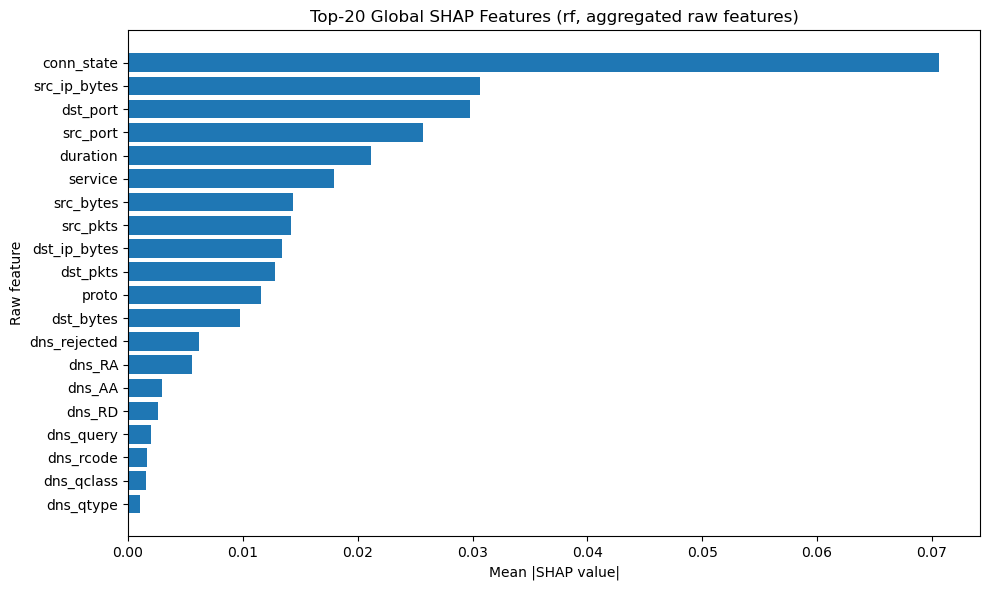


[Representative class summary plot]
Chosen class: xss


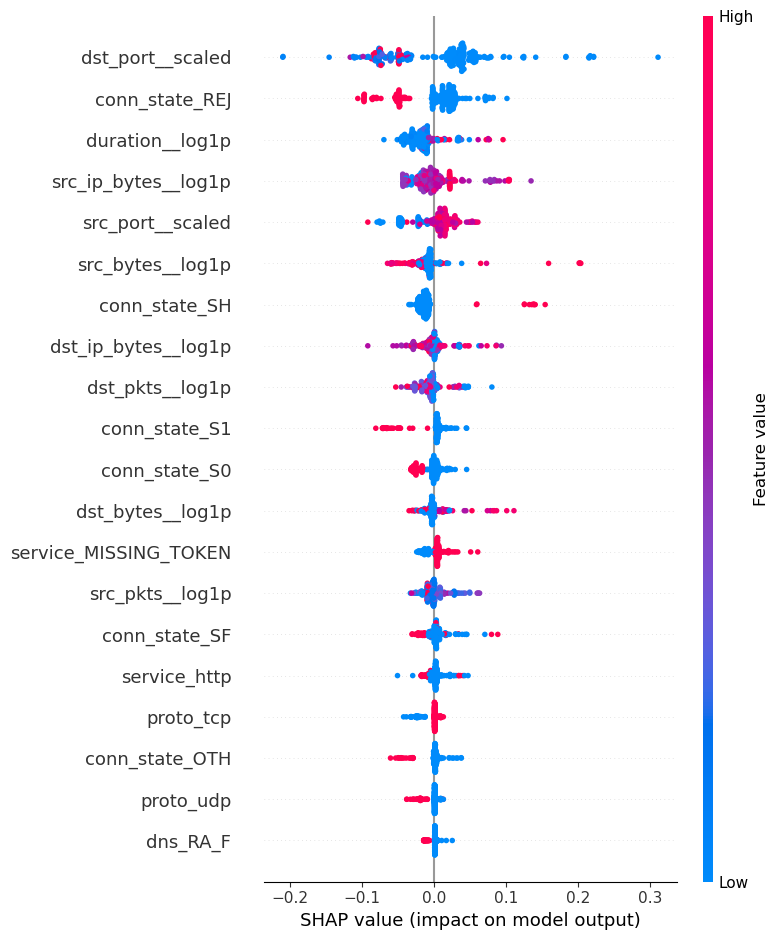


[Saved artifacts]
Directory: multiclass_shap_outputs

[Step 5B summary]
{
  "best_model": "rf",
  "shap_sample_size": 300,
  "transformed_feature_count": 154,
  "class_count": 9,
  "class_names": [
    "backdoor",
    "ddos",
    "dos",
    "injection",
    "normal",
    "password",
    "ransomware",
    "scanning",
    "xss"
  ],
  "representative_class_plot": "xss",
  "shap_time_seconds": 107.92542710000271
}

STEP 5B completed successfully in 108.5437 seconds.


In [31]:
# ============================================================
# STEP 5B: Multiclass SHAP analysis for selected RF model
# - computation-safe version for manuscript use
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("=" * 80)
print("STEP 5B: MULTICLASS SHAP ANALYSIS")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = [
    "best_model", "best_name",
    "X_test_raw", "y_test",
    "inv_label_mapping",
    "transformed_feature_names"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 5A first."

if best_name not in ["rf", "extratrees"]:
    raise ValueError(f"SHAP block currently expects a tree-based best model, got: {best_name}")

print("\n[Model for SHAP]")
print("Best model:", best_name)

# ------------------------------------------------------------------
# Get fitted preprocessor and classifier
# ------------------------------------------------------------------
preprocessor = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["clf"]

# ------------------------------------------------------------------
# Small sample for SHAP to keep runtime stable
# ------------------------------------------------------------------
MAX_SHAP_SAMPLES = min(300, len(X_test_raw))
X_shap_raw = X_test_raw.iloc[:MAX_SHAP_SAMPLES].copy()
y_shap = y_test.iloc[:MAX_SHAP_SAMPLES].copy() if isinstance(y_test, pd.Series) else pd.Series(y_test[:MAX_SHAP_SAMPLES])

print("\n[SHAP sample setup]")
print("Raw sample size:", len(X_shap_raw))

# transform using the fitted preprocessor
X_shap_trans = preprocessor.transform(X_shap_raw)

# convert sparse to dense if needed
if hasattr(X_shap_trans, "toarray"):
    X_shap_trans = X_shap_trans.toarray()

X_shap_trans = np.asarray(X_shap_trans)

print("Transformed SHAP matrix shape:", X_shap_trans.shape)
print("Number of transformed feature names:", len(transformed_feature_names))

assert X_shap_trans.shape[1] == len(transformed_feature_names), \
    "Mismatch between transformed matrix width and transformed feature names."

# ------------------------------------------------------------------
# SHAP computation
# ------------------------------------------------------------------
t_shap0 = time.perf_counter()

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap_trans)

t_shap = time.perf_counter() - t_shap0

print(f"\nSHAP computation time (s): {t_shap:.4f}")

# ------------------------------------------------------------------
# Normalize SHAP output shape
# Different SHAP versions may return:
# - list of arrays, one per class
# - single 3D array (samples, features, classes)
# ------------------------------------------------------------------
if isinstance(shap_values, list):
    # expected older behavior: list[n_classes] of (n_samples, n_features)
    shap_by_class = [np.asarray(sv) for sv in shap_values]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # shape may be (n_samples, n_features, n_classes)
    shap_by_class = [shap_values[:, :, k] for k in range(shap_values.shape[2])]
else:
    raise ValueError(f"Unexpected SHAP output structure: type={type(shap_values)}, shape={getattr(shap_values, 'shape', None)}")

n_classes = len(shap_by_class)
print("Detected SHAP class count:", n_classes)

class_names = [inv_label_mapping[i] for i in sorted(inv_label_mapping.keys())]
assert n_classes == len(class_names), \
    f"SHAP class count {n_classes} != label class count {len(class_names)}"

# ------------------------------------------------------------------
# Global mean absolute SHAP aggregated across all classes
# ------------------------------------------------------------------
mean_abs_shap_per_class = []
for k, sv in enumerate(shap_by_class):
    mean_abs = np.mean(np.abs(sv), axis=0)
    mean_abs_shap_per_class.append(mean_abs)

mean_abs_shap_per_class = np.vstack(mean_abs_shap_per_class)  # (n_classes, n_features)
global_mean_abs_shap = mean_abs_shap_per_class.mean(axis=0)

global_shap_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_abs_shap": global_mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n[Top 25 transformed features by global mean |SHAP|]")
print(global_shap_df.head(25))

# ------------------------------------------------------------------
# Aggregate transformed SHAP back to raw feature level
# ------------------------------------------------------------------
def map_transformed_to_raw_feature_name(fname):
    if fname.endswith("__log1p"):
        return fname.replace("__log1p", "")
    if fname.endswith("__scaled"):
        return fname.replace("__scaled", "")
    if fname.endswith("__freq"):
        return fname.replace("__freq", "")

    for c in sorted(low_mid_card_cat_cols, key=len, reverse=True):
        if fname.startswith(c + "_"):
            return c
    return fname

global_shap_raw_df = global_shap_df.copy()
global_shap_raw_df["raw_feature"] = global_shap_raw_df["feature"].apply(map_transformed_to_raw_feature_name)
global_shap_raw_df = global_shap_raw_df.groupby("raw_feature", as_index=False)["mean_abs_shap"].sum()
global_shap_raw_df = global_shap_raw_df.sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n[Top 25 raw features by aggregated global mean |SHAP|]")
print(global_shap_raw_df.head(25))

# ------------------------------------------------------------------
# Per-class SHAP tables
# ------------------------------------------------------------------
per_class_shap_tables = {}

for k, cname in enumerate(class_names):
    class_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "mean_abs_shap": mean_abs_shap_per_class[k]
    }).sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

    class_df["raw_feature"] = class_df["feature"].apply(map_transformed_to_raw_feature_name)
    class_raw_df = class_df.groupby("raw_feature", as_index=False)["mean_abs_shap"].sum()
    class_raw_df = class_raw_df.sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

    per_class_shap_tables[cname] = class_raw_df

    print("\n" + "-" * 80)
    print(f"[Top 10 raw SHAP features for class: {cname}]")
    print(class_raw_df.head(10))

# ------------------------------------------------------------------
# Plot global raw SHAP top features
# ------------------------------------------------------------------
TOPK = 20
top_global_raw = global_shap_raw_df.head(TOPK)

plt.figure(figsize=(10, 6))
plt.barh(top_global_raw["raw_feature"][::-1], top_global_raw["mean_abs_shap"][::-1])
plt.title(f"Top-{TOPK} Global SHAP Features ({best_name}, aggregated raw features)")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Raw feature")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Optional: SHAP summary plot for one representative class
# Choose the hardest class from Step 4 if available, else first class
# ------------------------------------------------------------------
preferred_class = "xss" if "xss" in class_names else class_names[0]
preferred_idx = class_names.index(preferred_class)

print("\n[Representative class summary plot]")
print("Chosen class:", preferred_class)

try:
    shap.summary_plot(
        shap_by_class[preferred_idx],
        X_shap_trans,
        feature_names=transformed_feature_names,
        show=True,
        max_display=20
    )
except Exception as e:
    print("SHAP summary plot warning:", e)

# ------------------------------------------------------------------
# Save artifacts
# ------------------------------------------------------------------
OUT_DIR = "multiclass_shap_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

global_shap_df.to_csv(os.path.join(OUT_DIR, "global_transformed_shap_importance.csv"), index=False)
global_shap_raw_df.to_csv(os.path.join(OUT_DIR, "global_raw_shap_importance.csv"), index=False)

for cname, class_df in per_class_shap_tables.items():
    safe_name = cname.replace("/", "_").replace(" ", "_")
    class_df.to_csv(os.path.join(OUT_DIR, f"shap_raw_importance_{safe_name}.csv"), index=False)

step5b_summary = {
    "best_model": best_name,
    "shap_sample_size": int(len(X_shap_raw)),
    "transformed_feature_count": int(X_shap_trans.shape[1]),
    "class_count": int(n_classes),
    "class_names": class_names,
    "representative_class_plot": preferred_class,
    "shap_time_seconds": float(t_shap)
}

with open(os.path.join(OUT_DIR, "step5b_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step5b_summary, f, indent=2)

t_step5b = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 5B summary]")
print(json.dumps(step5b_summary, indent=2))

print(f"\nSTEP 5B completed successfully in {t_step5b:.4f} seconds.")

In [32]:
# ============================================================
# STEP 6A: Multiclass forensic evidence logging
# - append-only hash-chained evidence records
# - alert = predicted class != normal
# - stores predicted class, confidence, top-k probabilities
# ============================================================

import os
import json
import time
import hashlib
import datetime
import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict

print("=" * 80)
print("STEP 6A: MULTICLASS FORENSIC EVIDENCE LOGGING")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = [
    "best_model", "best_name",
    "X_test_raw", "y_test", "ctx_test",
    "inv_label_mapping", "label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found."

assert "normal" in label_mapping, "'normal' class not found in label mapping."
NORMAL_CLASS_ID = label_mapping["normal"]

# ------------------------------------------------------------------
# Hash helpers
# ------------------------------------------------------------------
def sha256_hex(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def stable_hash(obj) -> str:
    s = json.dumps(obj, sort_keys=True, ensure_ascii=False, default=str).encode("utf-8")
    return sha256_hex(s)

# ------------------------------------------------------------------
# Evidence schema
# ------------------------------------------------------------------
@dataclass
class MultiClassEvidenceRecord:
    record_id: str
    created_utc: str
    case_id: str
    event_time: str
    context: dict

    model_name: str
    model_digest: str
    feature_schema_digest: str

    true_label_id: int
    true_label_name: str

    prediction_id: int
    prediction_name: str

    confidence: float
    score_type: str
    topk_predictions: list

    features_digest: str
    top_features: list

    prev_hash: str
    record_hash: str

# ------------------------------------------------------------------
# Record creation
# ------------------------------------------------------------------
def make_multiclass_evidence(
    case_id,
    idx,
    context,
    model_name,
    true_label_id,
    true_label_name,
    pred_id,
    pred_name,
    confidence,
    topk_predictions,
    features_row,
    prev_hash,
    *,
    model_digest="",
    feature_schema_digest="",
    score_type="max_class_probability",
    top_features=None
):
    created = datetime.datetime.utcnow().isoformat() + "Z"
    event_time = context.get("timestamp") or context.get("time") or created

    if top_features is None:
        top_features = []

    features_digest = stable_hash(features_row)

    core = {
        "record_id": f"{case_id}-{idx}",
        "created_utc": created,
        "case_id": case_id,
        "event_time": event_time,
        "context": context,

        "model_name": model_name,
        "model_digest": model_digest,
        "feature_schema_digest": feature_schema_digest,

        "true_label_id": int(true_label_id),
        "true_label_name": str(true_label_name),

        "prediction_id": int(pred_id),
        "prediction_name": str(pred_name),

        "confidence": float(confidence),
        "score_type": str(score_type),
        "topk_predictions": topk_predictions,

        "features_digest": features_digest,
        "top_features": top_features,

        "prev_hash": prev_hash
    }

    record_hash = stable_hash(core)
    return MultiClassEvidenceRecord(record_hash=record_hash, **core)

def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")

def verify_jsonl_hashchain(path):
    prev = "GENESIS"
    ok = True
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            rh = rec["record_hash"]
            core = {k: rec[k] for k in rec.keys() if k != "record_hash"}

            if core["prev_hash"] != prev:
                print("Broken link at:", core.get("record_id"))
                ok = False
            if stable_hash(core) != rh:
                print("Hash mismatch at:", core.get("record_id"))
                ok = False

            prev = rh
    return ok

# ------------------------------------------------------------------
# Prepare output paths
# ------------------------------------------------------------------
CASE_ID = f"CASE-{datetime.datetime.utcnow().strftime('%Y%m%d-%H%M%S')}"
OUT_DIR = "forensic_outputs_multiclass"
os.makedirs(OUT_DIR, exist_ok=True)

EVIDENCE_LOG = os.path.join(OUT_DIR, f"{CASE_ID}_evidence_multiclass.jsonl")

# ------------------------------------------------------------------
# Model metadata digests
# ------------------------------------------------------------------
feature_schema_digest = stable_hash(list(X_test_raw.columns))

model_meta = {
    "model_name": best_name,
    "params": best_model.get_params(),
    "normal_class_id": int(NORMAL_CLASS_ID),
    "label_mapping": label_mapping
}
model_digest = stable_hash(model_meta)

# ------------------------------------------------------------------
# Predictions and alert selection
# ------------------------------------------------------------------
t_pred0 = time.perf_counter()
y_pred = best_model.predict(X_test_raw)
y_proba = best_model.predict_proba(X_test_raw)
t_pred = time.perf_counter() - t_pred0

print("\n[Prediction runtime]")
print(f"Predict + predict_proba time (s): {t_pred:.4f}")

# alerts = non-normal predictions
alert_idxs = np.where(y_pred != NORMAL_CLASS_ID)[0]

print("\n[Alert summary]")
print("Total test samples        :", len(X_test_raw))
print("Predicted alerts          :", len(alert_idxs))
print("Predicted normal samples  :", int((y_pred == NORMAL_CLASS_ID).sum()))

# ------------------------------------------------------------------
# Rank alerts by confidence and keep top N for graph/log focus
# ------------------------------------------------------------------
N_ALERTS = min(500, len(alert_idxs))
alert_conf = y_proba[alert_idxs].max(axis=1)
top_alert_order = np.argsort(alert_conf)[::-1][:N_ALERTS]
top_alerts = alert_idxs[top_alert_order]

print("Alerts retained for evidence log:", len(top_alerts))

# ------------------------------------------------------------------
# Build top feature payload from SHAP global ranking if available
# ------------------------------------------------------------------
TOPK_EXPLAIN = 5
global_top_features = []

if "global_shap_raw_df" in globals():
    global_top_features = global_shap_raw_df["raw_feature"].head(20).tolist()
elif "xai_consensus_df" in globals():
    global_top_features = xai_consensus_df["raw_feature"].head(20).tolist()

print("\n[Explanation source for evidence payload]")
print(global_top_features[:10] if global_top_features else "No global feature ranking found.")

# reset aligned views
X_test_r = X_test_raw.reset_index(drop=True)
ctx_test_r = ctx_test.reset_index(drop=True)
y_test_r = pd.Series(y_test).reset_index(drop=True)

# ------------------------------------------------------------------
# Write evidence records
# ------------------------------------------------------------------
prev_hash = "GENESIS"

for j, i in enumerate(top_alerts):
    context = ctx_test_r.iloc[i].to_dict()
    feat_row = X_test_r.iloc[i].to_dict()

    pred_id = int(y_pred[i])
    pred_name = inv_label_mapping[pred_id]

    true_id = int(y_test_r.iloc[i])
    true_name = inv_label_mapping[true_id]

    proba_row = y_proba[i]
    confidence = float(np.max(proba_row))

    top3_idx = np.argsort(proba_row)[::-1][:3]
    topk_predictions = [
        {
            "class_id": int(k),
            "class_name": inv_label_mapping[int(k)],
            "probability": float(proba_row[k])
        }
        for k in top3_idx
    ]

    top_features = []
    for f in global_top_features[:TOPK_EXPLAIN]:
        if f in X_test_r.columns:
            val = X_test_r.loc[i, f]
            try:
                val = float(val)
            except Exception:
                val = str(val)

            top_features.append({
                "feature": f,
                "value": val,
                "contribution": None
            })

    rec = make_multiclass_evidence(
        case_id=CASE_ID,
        idx=j,
        context=context,
        model_name=best_name,
        true_label_id=true_id,
        true_label_name=true_name,
        pred_id=pred_id,
        pred_name=pred_name,
        confidence=confidence,
        topk_predictions=topk_predictions,
        features_row=feat_row,
        prev_hash=prev_hash,
        model_digest=model_digest,
        feature_schema_digest=feature_schema_digest,
        score_type="max_class_probability",
        top_features=top_features
    )

    append_jsonl(EVIDENCE_LOG, asdict(rec))
    prev_hash = rec.record_hash

# ------------------------------------------------------------------
# Final verification
# ------------------------------------------------------------------
hash_ok = verify_jsonl_hashchain(EVIDENCE_LOG)
t_step6a = time.perf_counter() - t0

print("\n[Evidence log output]")
print("Case ID              :", CASE_ID)
print("Evidence log path    :", EVIDENCE_LOG)
print("Hash-chain verified  :", hash_ok)

print(f"\nSTEP 6A completed successfully in {t_step6a:.4f} seconds.")

STEP 6A: MULTICLASS FORENSIC EVIDENCE LOGGING

[Prediction runtime]
Predict + predict_proba time (s): 0.9354

[Alert summary]
Total test samples        : 37887
Predicted alerts          : 29476
Predicted normal samples  : 8411
Alerts retained for evidence log: 500

[Explanation source for evidence payload]
['conn_state', 'src_ip_bytes', 'dst_port', 'src_port', 'duration', 'service', 'src_bytes', 'src_pkts', 'dst_ip_bytes', 'dst_pkts']

[Evidence log output]
Case ID              : CASE-20260312-195546
Evidence log path    : forensic_outputs_multiclass\CASE-20260312-195546_evidence_multiclass.jsonl
Hash-chain verified  : True

STEP 6A completed successfully in 1.4154 seconds.


In [34]:
# ============================================================
# STEP 6B / STEP 7: Multiclass evidence graph construction
# + host interaction graph + manuscript-ready graph statistics
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
from collections import Counter, defaultdict

print("=" * 80)
print("STEP 6B / STEP 7: MULTICLASS EVIDENCE GRAPH + HOST GRAPH")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = [
    "EVIDENCE_LOG", "CASE_ID", "inv_label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 6A first."

assert os.path.exists(EVIDENCE_LOG), f"Evidence log not found: {EVIDENCE_LOG}"

# ------------------------------------------------------------------
# Graph containers
# ------------------------------------------------------------------
G = nx.DiGraph()   # evidence graph: hosts + evidence nodes
H = nx.DiGraph()   # host interaction graph

host_pair_counts = Counter()
host_pair_class_counts = defaultdict(Counter)
host_alert_counts = Counter()
class_counts = Counter()
confidence_by_class = defaultdict(list)

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def add_node_safe(graph, node_id, **attrs):
    if node_id is None or node_id == "":
        return
    if not graph.has_node(node_id):
        graph.add_node(node_id, **attrs)
    else:
        for k, v in attrs.items():
            if k not in graph.nodes[node_id]:
                graph.nodes[node_id][k] = v

def add_edge_weighted(graph, u, v, relation=None, **attrs):
    if not u or not v:
        return

    if graph.has_edge(u, v):
        graph[u][v]["weight"] = graph[u][v].get("weight", 1) + 1
    else:
        graph.add_edge(u, v, relation=relation, weight=1, **attrs)

# ------------------------------------------------------------------
# Read evidence log and construct graphs
# ------------------------------------------------------------------
with open(EVIDENCE_LOG, "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)

        rid = rec["record_id"]
        pred_name = rec.get("prediction_name", "unknown")
        pred_id = rec.get("prediction_id", -1)
        true_name = rec.get("true_label_name", "unknown")
        confidence = float(rec.get("confidence", 0.0))
        etime = rec.get("event_time", "")
        context = rec.get("context", {}) if isinstance(rec.get("context"), dict) else {}

        src_ip = context.get("src_ip")
        dst_ip = context.get("dst_ip")
        src_port = context.get("src_port")
        dst_port = context.get("dst_port")
        proto = context.get("proto")
        service = context.get("service")
        conn_state = context.get("conn_state")

        # ---------------------------
        # Evidence node
        # ---------------------------
        add_node_safe(
            G,
            rid,
            kind="evidence",
            prediction_name=pred_name,
            prediction_id=pred_id,
            true_label_name=true_name,
            confidence=confidence,
            event_time=etime
        )

        class_counts[pred_name] += 1
        confidence_by_class[pred_name].append(confidence)

        # ---------------------------
        # Host nodes + evidence edges
        # ---------------------------
        if src_ip:
            add_node_safe(G, src_ip, kind="host")
            add_edge_weighted(
                G, src_ip, rid,
                relation="generated",
                proto=proto,
                service=service,
                conn_state=conn_state
            )
            host_alert_counts[src_ip] += 1

        if dst_ip:
            add_node_safe(G, dst_ip, kind="host")
            add_edge_weighted(
                G, rid, dst_ip,
                relation="targeted",
                proto=proto,
                service=service,
                conn_state=conn_state
            )
            host_alert_counts[dst_ip] += 1

        # ---------------------------
        # Host-to-host graph
        # ---------------------------
        if src_ip and dst_ip:
            host_pair_counts[(src_ip, dst_ip)] += 1
            host_pair_class_counts[(src_ip, dst_ip)][pred_name] += 1

            if not H.has_node(src_ip):
                H.add_node(src_ip, kind="host")
            if not H.has_node(dst_ip):
                H.add_node(dst_ip, kind="host")

            if H.has_edge(src_ip, dst_ip):
                H[src_ip][dst_ip]["weight"] += 1
                H[src_ip][dst_ip]["class_counts"][pred_name] = H[src_ip][dst_ip]["class_counts"].get(pred_name, 0) + 1
            else:
                H.add_edge(
                    src_ip, dst_ip,
                    relation="communicates",
                    weight=1,
                    class_counts={pred_name: 1}
                )

# ------------------------------------------------------------------
# Graph summary statistics
# ------------------------------------------------------------------
t_graph = time.perf_counter() - t0

print("\n[Evidence graph summary]")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print("\n[Host interaction graph summary]")
print("Nodes:", H.number_of_nodes())
print("Edges:", H.number_of_edges())

print(f"\nGraph construction time (s): {t_graph:.4f}")

# ------------------------------------------------------------------
# Top nodes by degree
# ------------------------------------------------------------------
top_evidence_graph_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:15]
top_host_graph_nodes = sorted(H.degree, key=lambda x: x[1], reverse=True)[:15]

print("\n[Top evidence-graph nodes by degree]")
print(top_evidence_graph_nodes)

print("\n[Top host-graph nodes by degree]")
print(top_host_graph_nodes)

# ------------------------------------------------------------------
# Alert class distribution in evidence graph
# ------------------------------------------------------------------
class_dist_df = pd.DataFrame({
    "predicted_class": list(class_counts.keys()),
    "count": list(class_counts.values()),
    "percent": [100 * c / max(sum(class_counts.values()), 1) for c in class_counts.values()],
    "mean_confidence": [np.mean(confidence_by_class[k]) if len(confidence_by_class[k]) > 0 else 0.0 for k in class_counts.keys()]
}).sort_values(by="count", ascending=False).reset_index(drop=True)

print("\n[Evidence-node class distribution]")
print(class_dist_df)

# ------------------------------------------------------------------
# Top suspicious host pairs
# ------------------------------------------------------------------
pair_rows = []
for (src, dst), w in host_pair_counts.items():
    class_counter = host_pair_class_counts[(src, dst)]
    top_class, top_class_count = class_counter.most_common(1)[0]

    pair_rows.append({
        "src_ip": src,
        "dst_ip": dst,
        "edge_weight": w,
        "dominant_class": top_class,
        "dominant_class_count": top_class_count,
        "class_breakdown": dict(class_counter)
    })

host_pair_df = pd.DataFrame(pair_rows).sort_values(
    by=["edge_weight", "dominant_class_count"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n[Top 20 suspicious host pairs]")
print(host_pair_df.head(20))

# ------------------------------------------------------------------
# Top suspicious hosts
# ------------------------------------------------------------------
host_alert_df = pd.DataFrame({
    "host": list(host_alert_counts.keys()),
    "alert_count": list(host_alert_counts.values())
}).sort_values(by="alert_count", ascending=False).reset_index(drop=True)

print("\n[Top 20 suspicious hosts by alert participation]")
print(host_alert_df.head(20))

# ------------------------------------------------------------------
# Edge-level class summary for host graph
# ------------------------------------------------------------------
host_graph_edge_rows = []
for u, v, data in H.edges(data=True):
    class_counter = data.get("class_counts", {})
    dominant_class = None
    dominant_count = 0
    if len(class_counter) > 0:
        dominant_class, dominant_count = sorted(class_counter.items(), key=lambda x: x[1], reverse=True)[0]

    host_graph_edge_rows.append({
        "src_ip": u,
        "dst_ip": v,
        "weight": data.get("weight", 0),
        "dominant_class": dominant_class,
        "dominant_class_count": dominant_count,
        "class_counts": class_counter
    })

host_graph_edges_df = pd.DataFrame(host_graph_edge_rows).sort_values(
    by=["weight", "dominant_class_count"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n[Top 20 host-graph edges]")
print(host_graph_edges_df.head(20))

# ------------------------------------------------------------------
# Save graph artifacts
# ------------------------------------------------------------------
OUT_DIR = "multiclass_graph_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

class_dist_df.to_csv(os.path.join(OUT_DIR, "evidence_class_distribution.csv"), index=False)
host_pair_df.to_csv(os.path.join(OUT_DIR, "top_host_pairs.csv"), index=False)
host_alert_df.to_csv(os.path.join(OUT_DIR, "top_hosts_by_alert_count.csv"), index=False)
host_graph_edges_df.to_csv(os.path.join(OUT_DIR, "host_graph_edges.csv"), index=False)

# ------------------------------------------------------------------
# Make GraphML-safe copies of graphs
# GraphML does not support dict/list attributes directly
# ------------------------------------------------------------------
def make_graphml_safe_graph(graph):
    G_safe = graph.copy()

    # node attributes
    for n, attrs in G_safe.nodes(data=True):
        for k, v in list(attrs.items()):
            if isinstance(v, (dict, list, tuple, set)):
                G_safe.nodes[n][k] = json.dumps(v, ensure_ascii=False, default=str)
            elif v is None:
                G_safe.nodes[n][k] = ""
            elif isinstance(v, bool):
                G_safe.nodes[n][k] = int(v)

    # edge attributes
    for u, v, attrs in G_safe.edges(data=True):
        for k, val in list(attrs.items()):
            if isinstance(val, (dict, list, tuple, set)):
                G_safe[u][v][k] = json.dumps(val, ensure_ascii=False, default=str)
            elif val is None:
                G_safe[u][v][k] = ""
            elif isinstance(val, bool):
                G_safe[u][v][k] = int(val)

    return G_safe

G_graphml = make_graphml_safe_graph(G)
H_graphml = make_graphml_safe_graph(H)

nx.write_graphml(G_graphml, os.path.join(OUT_DIR, f"{CASE_ID}_evidence_graph.graphml"))
nx.write_graphml(H_graphml, os.path.join(OUT_DIR, f"{CASE_ID}_host_graph.graphml"))

graph_summary = {
    "case_id": CASE_ID,
    "evidence_graph_nodes": int(G.number_of_nodes()),
    "evidence_graph_edges": int(G.number_of_edges()),
    "host_graph_nodes": int(H.number_of_nodes()),
    "host_graph_edges": int(H.number_of_edges()),
    "predicted_alert_count_logged": int(sum(class_counts.values())),
    "class_distribution": class_dist_df.to_dict(orient="records")[:20]
}

with open(os.path.join(OUT_DIR, "graph_summary.json"), "w", encoding="utf-8") as f:
    json.dump(graph_summary, f, indent=2)

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Graph summary]")
print(json.dumps(graph_summary, indent=2))

print(f"\nSTEP 6B / STEP 7 completed successfully in {t_graph:.4f} seconds.")

STEP 6B / STEP 7: MULTICLASS EVIDENCE GRAPH + HOST GRAPH

[Evidence graph summary]
Nodes: 528
Edges: 1000

[Host interaction graph summary]
Nodes: 28
Edges: 51

Graph construction time (s): 0.0172

[Top evidence-graph nodes by degree]
[('192.168.1.30', 207), ('192.168.1.193', 145), ('192.168.1.31', 103), ('192.168.1.32', 69), ('192.168.1.152', 68), ('192.168.1.37', 63), ('192.168.1.190', 63), ('192.168.1.33', 55), ('192.168.1.184', 37), ('192.168.1.1', 27), ('192.168.1.195', 26), ('192.168.1.49', 22), ('176.28.50.165', 19), ('192.168.1.194', 13), ('192.168.1.133', 12)]

[Top host-graph nodes by degree]
[('192.168.1.30', 17), ('192.168.1.32', 14), ('192.168.1.31', 13), ('192.168.1.193', 6), ('192.168.1.152', 4), ('192.168.1.190', 4), ('192.168.1.133', 3), ('176.28.50.165', 3), ('192.168.1.49', 3), ('192.168.1.186', 3), ('192.168.1.195', 3), ('192.168.1.33', 2), ('192.168.1.37', 2), ('192.168.1.184', 2), ('192.168.1.194', 2)]

[Evidence-node class distribution]
  predicted_class  count  

STEP 7B: PAPER-STYLE GRAPH VISUALIZATION


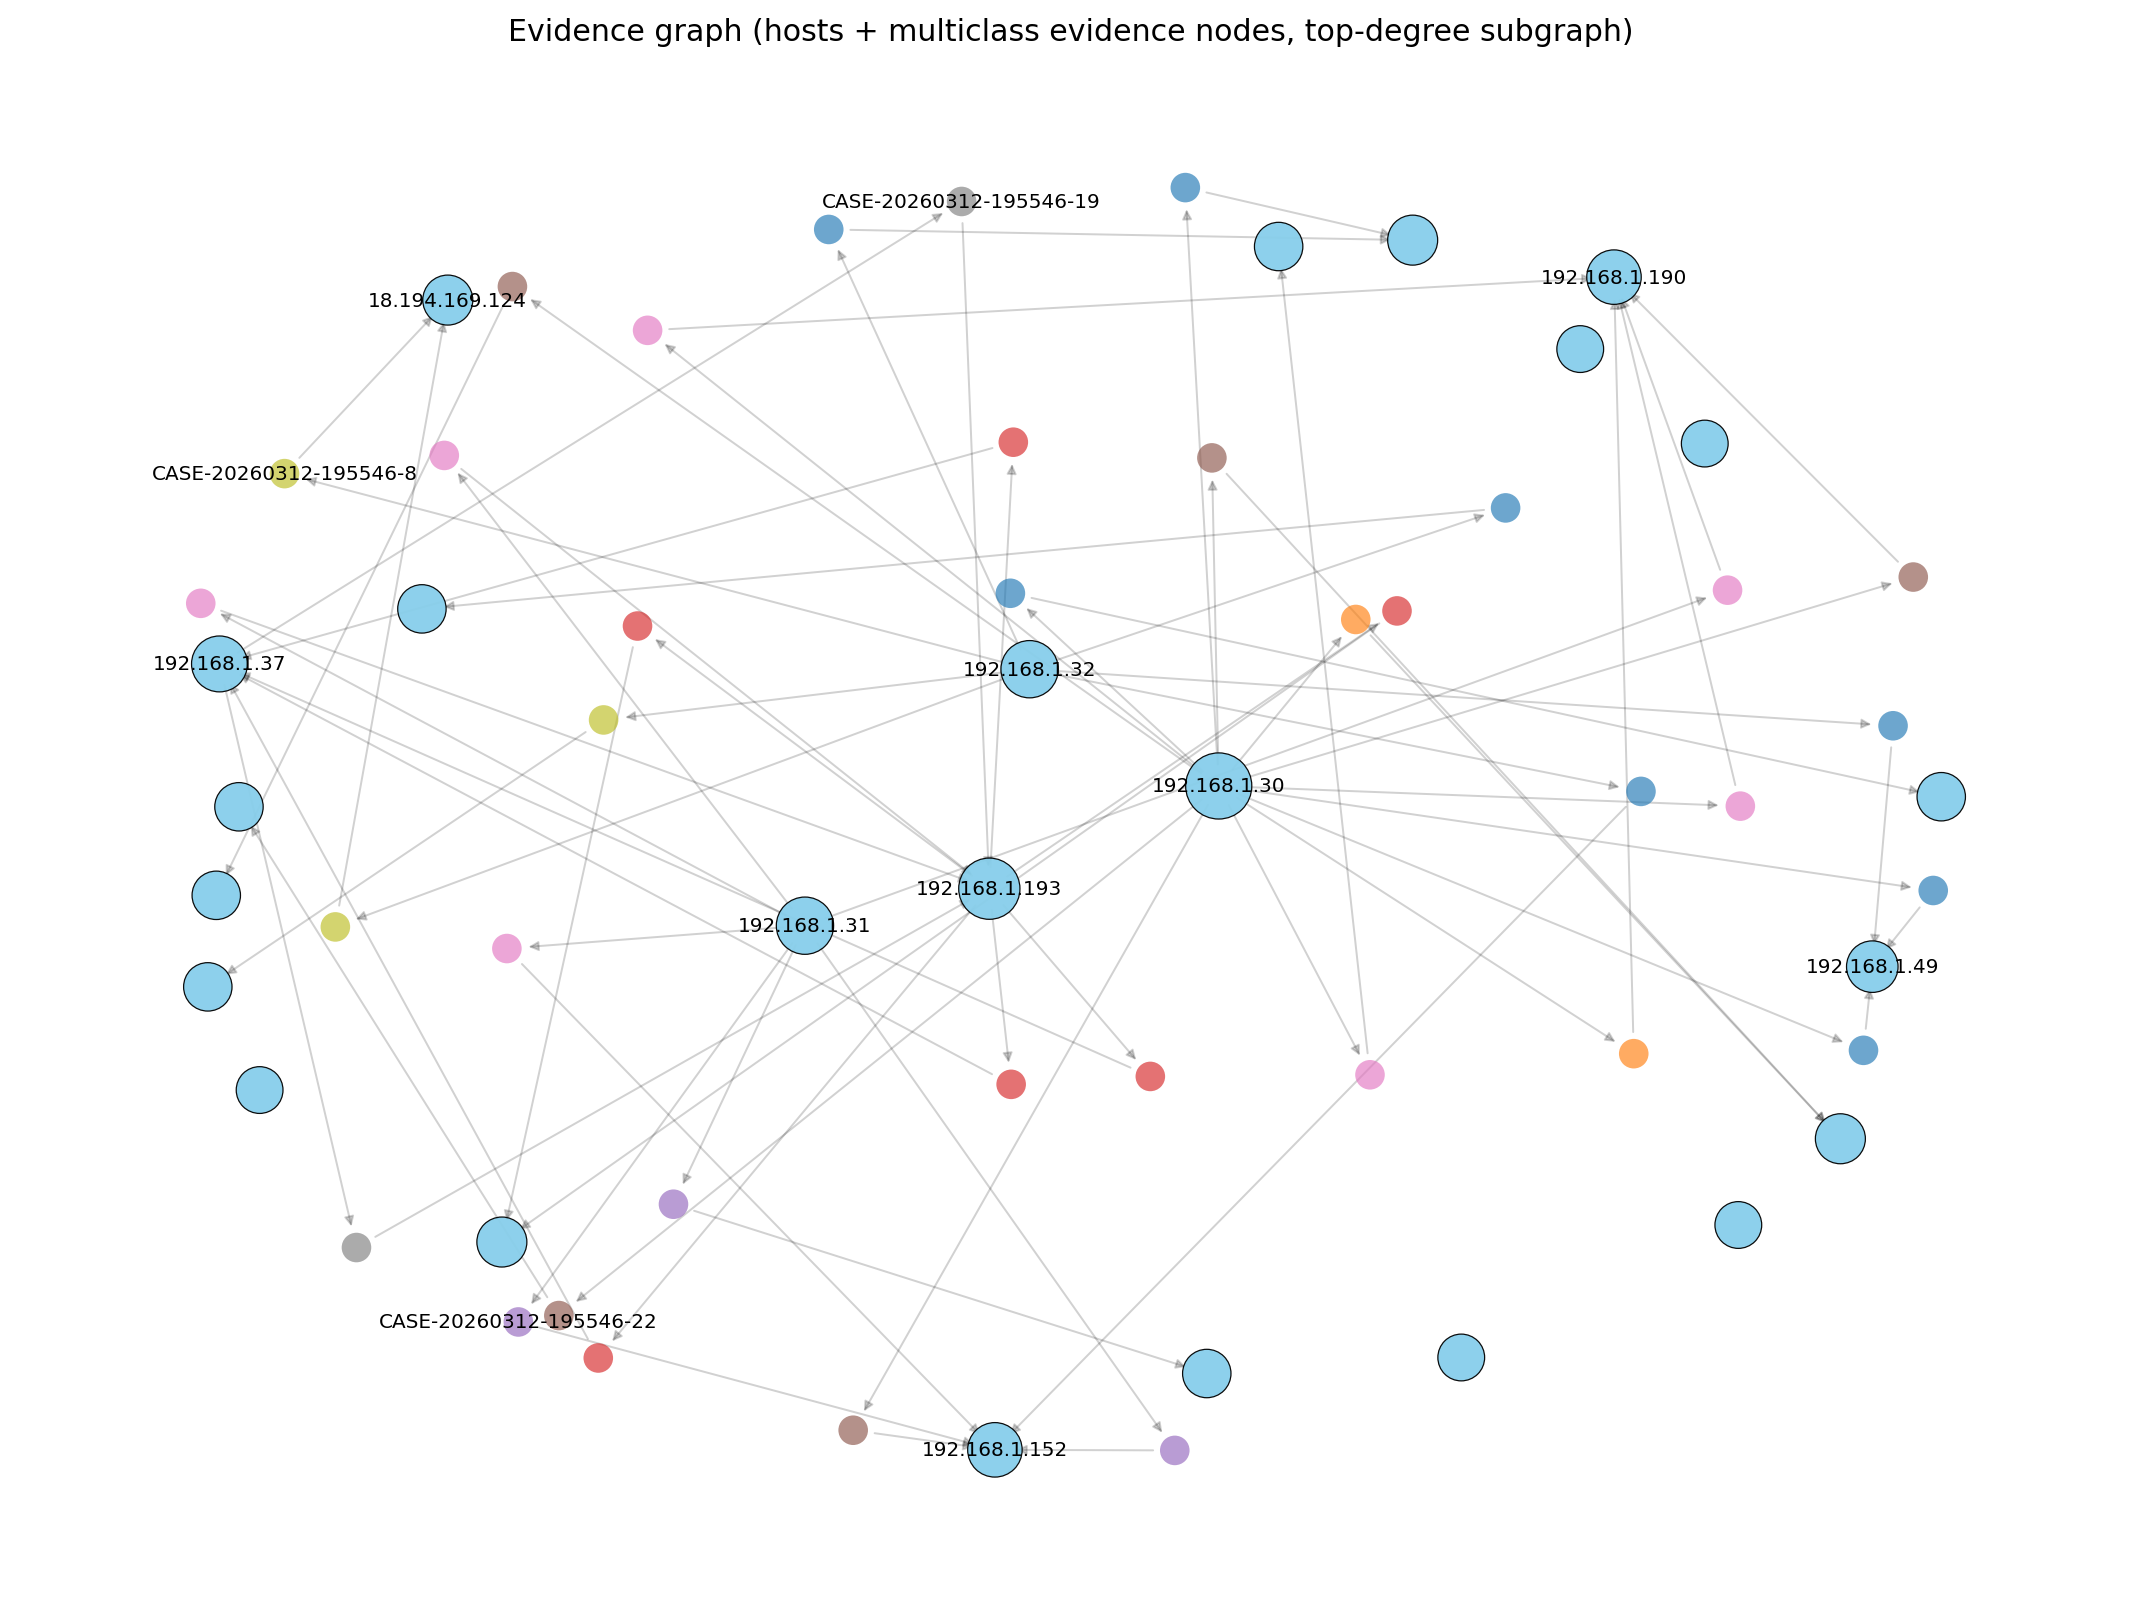

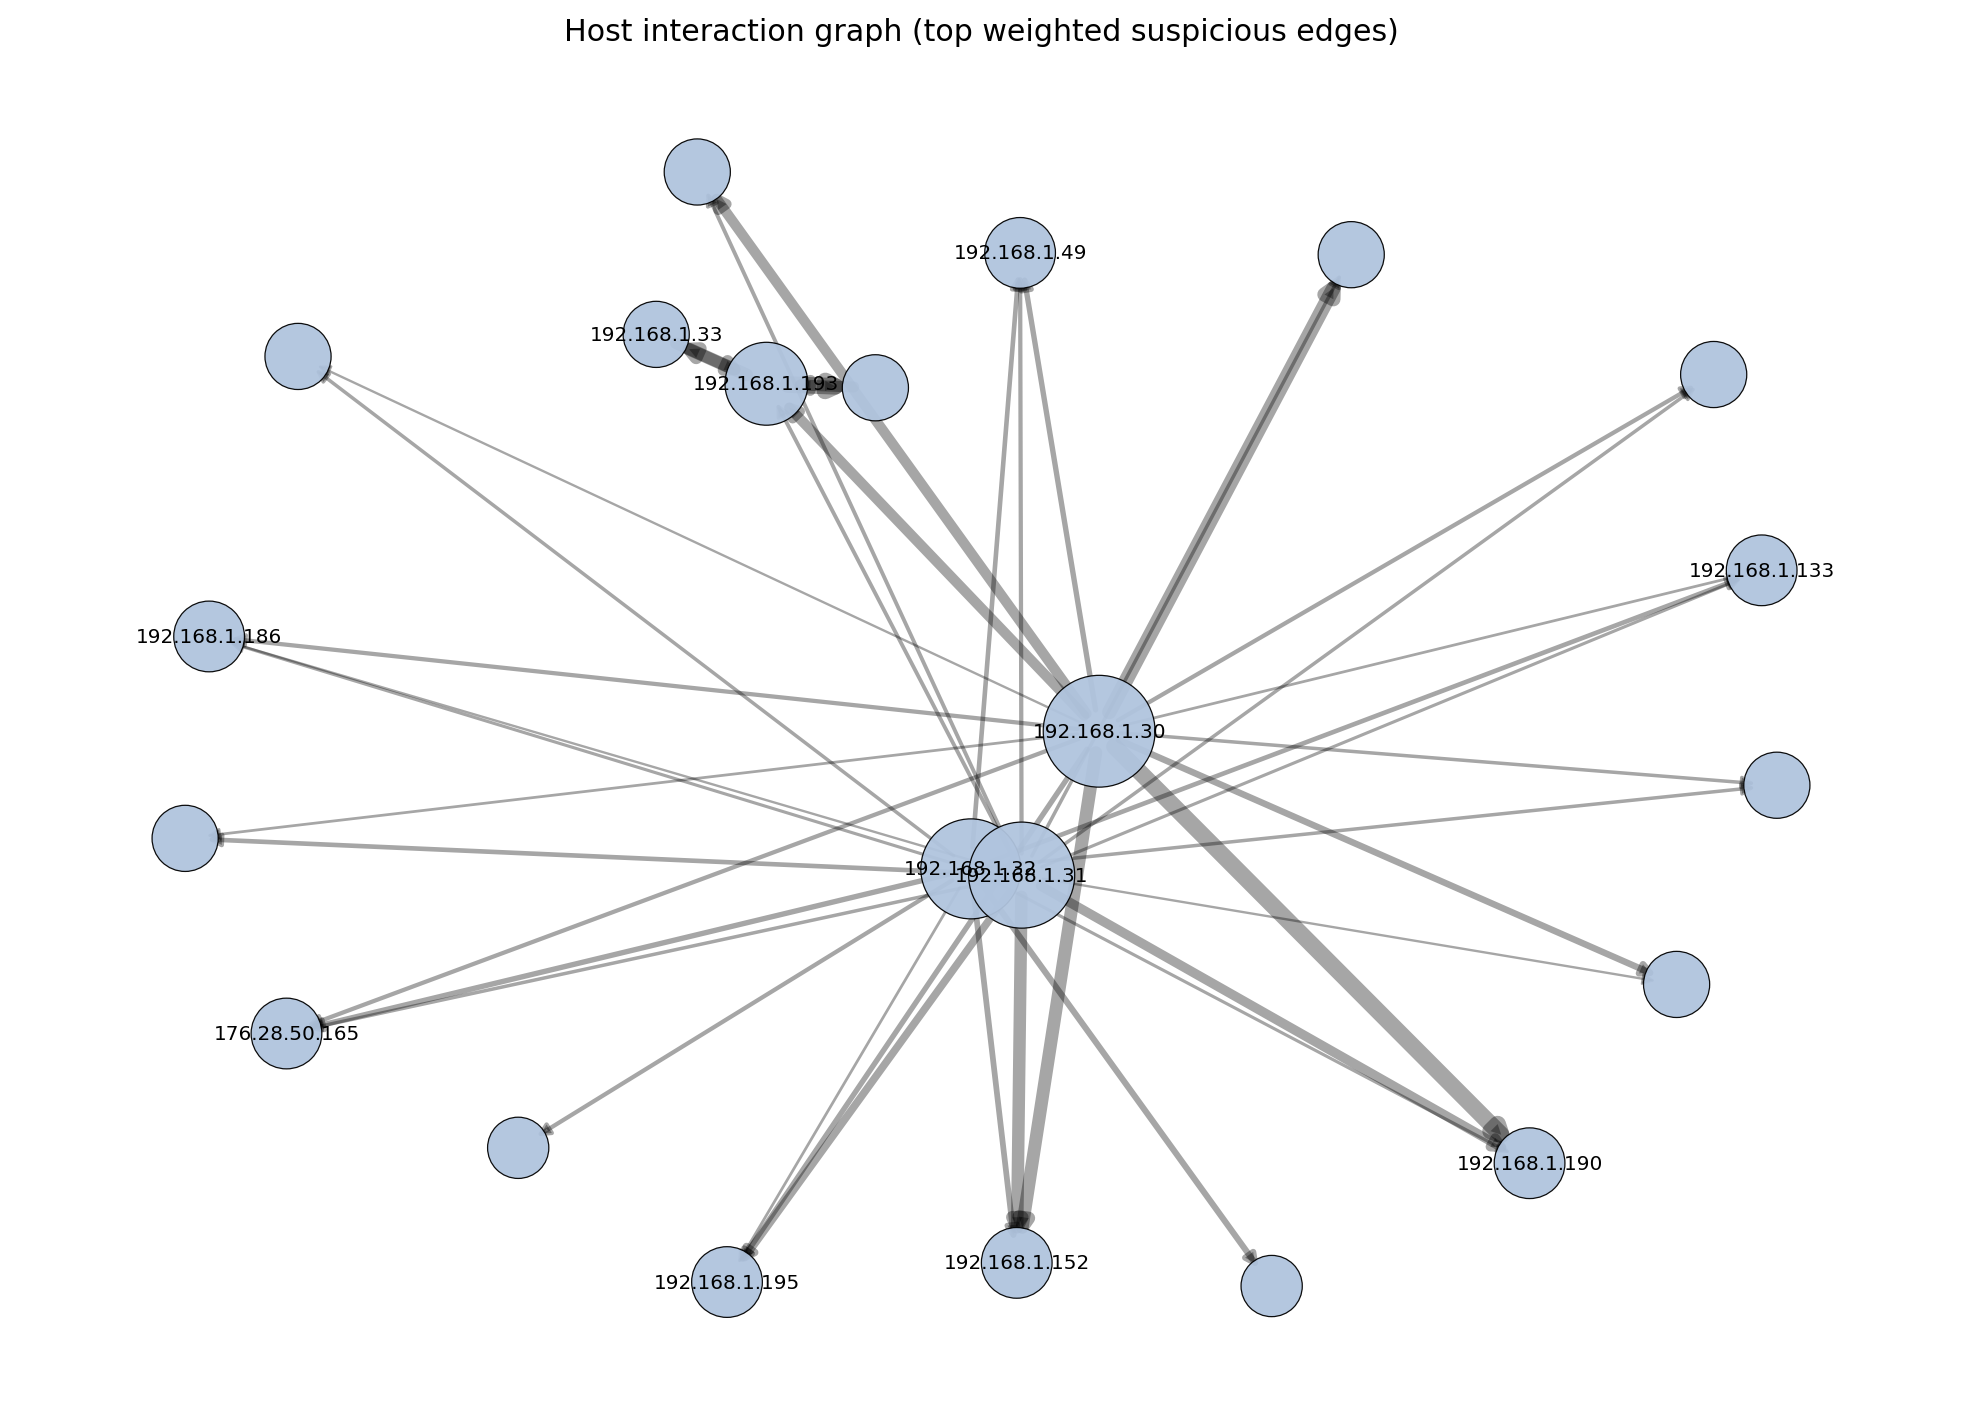

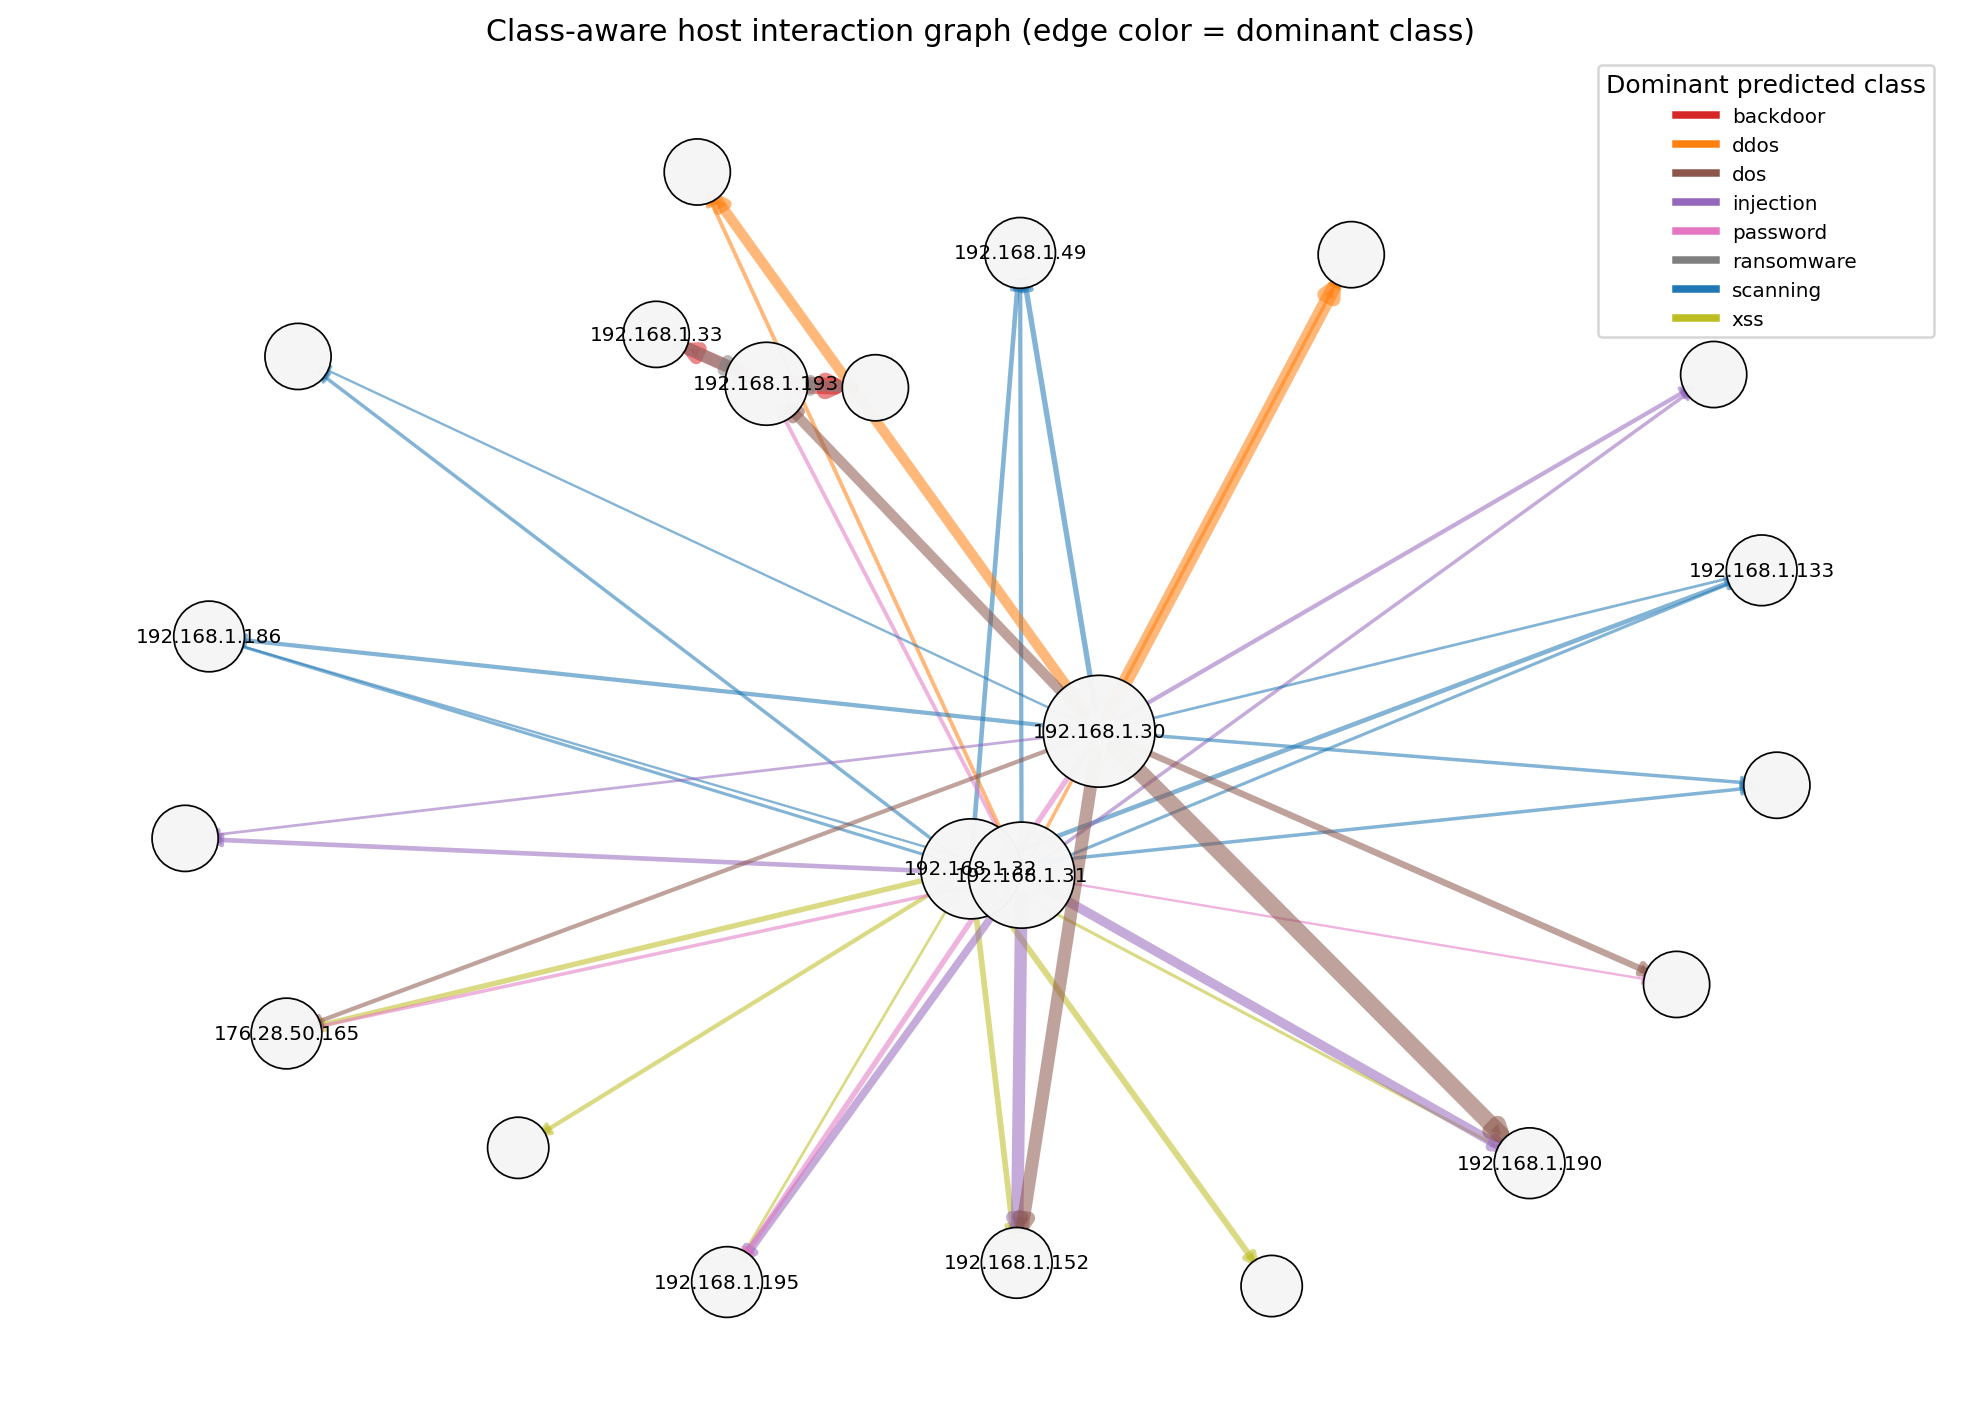


[Saved plot files]
multiclass_graph_outputs\CASE-20260312-195546_evidence_graph_topk.png
multiclass_graph_outputs\CASE-20260312-195546_evidence_graph_topk.pdf
multiclass_graph_outputs\CASE-20260312-195546_host_graph_top_edges.png
multiclass_graph_outputs\CASE-20260312-195546_host_graph_top_edges.pdf
multiclass_graph_outputs\CASE-20260312-195546_host_graph_class_aware.png
multiclass_graph_outputs\CASE-20260312-195546_host_graph_class_aware.pdf

STEP 7B completed successfully.


In [36]:
# ============================================================
# STEP 7B: Paper-style graph visualization
# - evidence graph
# - host interaction graph
# - class-aware host graph
# ============================================================

import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

print("=" * 80)
print("STEP 7B: PAPER-STYLE GRAPH VISUALIZATION")
print("=" * 80)

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = ["G", "H", "CASE_ID"]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 6B/7 first."

OUT_DIR = "multiclass_graph_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# Class-to-color mapping (stable, readable)
# We let matplotlib choose named colors for clarity
# ------------------------------------------------------------------
CLASS_COLOR_MAP = {
    "backdoor": "tab:red",
    "ddos": "tab:orange",
    "dos": "tab:brown",
    "injection": "tab:purple",
    "normal": "tab:green",
    "password": "tab:pink",
    "ransomware": "tab:gray",
    "scanning": "tab:blue",
    "xss": "tab:olive",
    "unknown": "black"
}

# ------------------------------------------------------------------
# 1) Evidence graph: curated top-degree subgraph
# ------------------------------------------------------------------
def plot_evidence_graph_topk(G, k=60, seed=42, save_prefix="evidence_graph_topk"):
    top_nodes = [n for n, d in sorted(G.degree, key=lambda x: x[1], reverse=True)[:k]]
    SG = G.subgraph(top_nodes).copy()

    plt.figure(figsize=(12, 9), dpi=180)
    pos = nx.spring_layout(SG, seed=seed, k=0.9)

    host_nodes = [n for n in SG.nodes() if SG.nodes[n].get("kind") == "host"]
    evidence_nodes = [n for n in SG.nodes() if SG.nodes[n].get("kind") == "evidence"]

    host_sizes = [350 + 25 * SG.degree(n) for n in host_nodes]
    evidence_sizes = [120 + 10 * SG.degree(n) for n in evidence_nodes]

    # evidence node color by predicted class
    evidence_colors = [
        CLASS_COLOR_MAP.get(SG.nodes[n].get("prediction_name", "unknown"), "black")
        for n in evidence_nodes
    ]

    nx.draw_networkx_edges(
        SG, pos,
        alpha=0.18,
        arrows=True,
        arrowsize=8,
        width=0.8
    )

    nx.draw_networkx_nodes(
        SG, pos,
        nodelist=host_nodes,
        node_size=host_sizes,
        node_color="skyblue",
        alpha=0.95,
        edgecolors="black",
        linewidths=0.5
    )

    nx.draw_networkx_nodes(
        SG, pos,
        nodelist=evidence_nodes,
        node_size=evidence_sizes,
        node_color=evidence_colors,
        alpha=0.65,
        edgecolors="none"
    )

    label_nodes = [n for n, d in sorted(SG.degree, key=lambda x: x[1], reverse=True)[:12]]
    labels = {n: str(n) for n in label_nodes}
    nx.draw_networkx_labels(SG, pos, labels=labels, font_size=8)

    plt.title("Evidence graph (hosts + multiclass evidence nodes, top-degree subgraph)")
    plt.axis("off")
    plt.tight_layout()

    png_path = os.path.join(OUT_DIR, f"{save_prefix}.png")
    pdf_path = os.path.join(OUT_DIR, f"{save_prefix}.pdf")
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return png_path, pdf_path

# ------------------------------------------------------------------
# 2) Host interaction graph: top weighted edges
# ------------------------------------------------------------------
def plot_host_graph_top_edges(H, top_edges=30, seed=42, save_prefix="host_graph_top_edges"):
    edges_sorted = sorted(H.edges(data=True), key=lambda e: e[2].get("weight", 1), reverse=True)[:top_edges]

    keep_nodes = set()
    for u, v, _ in edges_sorted:
        keep_nodes.add(u)
        keep_nodes.add(v)

    SG = H.subgraph(list(keep_nodes)).copy()

    plt.figure(figsize=(11, 8), dpi=180)
    pos = nx.spring_layout(SG, seed=seed, k=1.0)

    node_sizes = [500 + 100 * SG.degree(n) for n in SG.nodes()]
    edge_widths = [0.8 + 0.15 * SG[u][v].get("weight", 1) for u, v in SG.edges()]

    nx.draw_networkx_nodes(
        SG, pos,
        node_size=node_sizes,
        node_color="lightsteelblue",
        alpha=0.95,
        edgecolors="black",
        linewidths=0.5
    )
    nx.draw_networkx_edges(
        SG, pos,
        width=edge_widths,
        alpha=0.35,
        arrows=True,
        arrowsize=10
    )

    # labels = {n: str(n) for n in sorted(SG.degree, key=lambda x: x[1], reverse=True)[:12]}
    top_label_nodes = [n for n, d in sorted(SG.degree, key=lambda x: x[1], reverse=True)[:12]]
    labels = {n: str(n) for n in top_label_nodes}
    nx.draw_networkx_labels(SG, pos, labels=labels, font_size=8)

    plt.title("Host interaction graph (top weighted suspicious edges)")
    plt.axis("off")
    plt.tight_layout()

    png_path = os.path.join(OUT_DIR, f"{save_prefix}.png")
    pdf_path = os.path.join(OUT_DIR, f"{save_prefix}.pdf")
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return png_path, pdf_path

# ------------------------------------------------------------------
# 3) Class-aware host graph
# Edge color by dominant predicted class
# ------------------------------------------------------------------
def plot_class_aware_host_graph(H, top_edges=30, seed=42, save_prefix="host_graph_class_aware"):
    edges_sorted = sorted(H.edges(data=True), key=lambda e: e[2].get("weight", 1), reverse=True)[:top_edges]

    keep_nodes = set()
    for u, v, _ in edges_sorted:
        keep_nodes.add(u)
        keep_nodes.add(v)

    SG = H.subgraph(list(keep_nodes)).copy()

    plt.figure(figsize=(11, 8), dpi=180)
    pos = nx.spring_layout(SG, seed=seed, k=1.0)

    node_sizes = [500 + 100 * SG.degree(n) for n in SG.nodes()]

    edge_colors = []
    edge_widths = []

    for u, v, data in SG.edges(data=True):
        class_counts = data.get("class_counts", {})
        dominant_class = "unknown"
        if isinstance(class_counts, dict) and len(class_counts) > 0:
            dominant_class = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[0][0]

        edge_colors.append(CLASS_COLOR_MAP.get(dominant_class, "black"))
        edge_widths.append(0.8 + 0.15 * data.get("weight", 1))

    nx.draw_networkx_nodes(
        SG, pos,
        node_size=node_sizes,
        node_color="whitesmoke",
        alpha=0.98,
        edgecolors="black",
        linewidths=0.7
    )
    nx.draw_networkx_edges(
        SG, pos,
        edge_color=edge_colors,
        width=edge_widths,
        alpha=0.55,
        arrows=True,
        arrowsize=10
    )

    # labels = {n: str(n) for n in sorted(SG.degree, key=lambda x: x[1], reverse=True)[:12]}
    top_label_nodes = [n for n, d in sorted(SG.degree, key=lambda x: x[1], reverse=True)[:12]]
    labels = {n: str(n) for n in top_label_nodes}
    nx.draw_networkx_labels(SG, pos, labels=labels, font_size=8)

    # legend
    legend_classes = sorted({ 
        sorted(data.get("class_counts", {}).items(), key=lambda x: x[1], reverse=True)[0][0]
        for _, _, data in SG.edges(data=True)
        if isinstance(data.get("class_counts", {}), dict) and len(data.get("class_counts", {})) > 0
    })

    handles = []
    for cls in legend_classes:
        handles.append(plt.Line2D([0], [0], color=CLASS_COLOR_MAP.get(cls, "black"), lw=3, label=cls))

    if handles:
        plt.legend(handles=handles, title="Dominant predicted class", loc="best", fontsize=8)

    plt.title("Class-aware host interaction graph (edge color = dominant class)")
    plt.axis("off")
    plt.tight_layout()

    png_path = os.path.join(OUT_DIR, f"{save_prefix}.png")
    pdf_path = os.path.join(OUT_DIR, f"{save_prefix}.pdf")
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return png_path, pdf_path

# ------------------------------------------------------------------
# Generate plots
# ------------------------------------------------------------------
ev_png, ev_pdf = plot_evidence_graph_topk(G, k=60, seed=42, save_prefix=f"{CASE_ID}_evidence_graph_topk")
hg_png, hg_pdf = plot_host_graph_top_edges(H, top_edges=30, seed=42, save_prefix=f"{CASE_ID}_host_graph_top_edges")
cg_png, cg_pdf = plot_class_aware_host_graph(H, top_edges=30, seed=42, save_prefix=f"{CASE_ID}_host_graph_class_aware")

print("\n[Saved plot files]")
print(ev_png)
print(ev_pdf)
print(hg_png)
print(hg_pdf)
print(cg_png)
print(cg_pdf)

print("\nSTEP 7B completed successfully.")

STEP 8: FORENSIC TIMELINE RECONSTRUCTION

[Evidence log loaded]
Number of logged alerts: 500
Columns:
['record_id', 'created_utc', 'case_id', 'event_time', 'context', 'model_name', 'model_digest', 'feature_schema_digest', 'true_label_id', 'true_label_name', 'prediction_id', 'prediction_name', 'confidence', 'score_type', 'topk_predictions', 'features_digest', 'top_features', 'prev_hash', 'record_hash']

[Timeline parsing status]
Valid created_utc ratio : 1.0000
Valid event_time ratio  : 1.0000

[Timeline summary]
{
  "case_id": "CASE-20260312-195546",
  "logged_alerts": 500,
  "classes_present": [
    "backdoor",
    "ddos",
    "dos",
    "injection",
    "password",
    "ransomware",
    "scanning",
    "xss"
  ],
  "timeline_start_created_utc": "2026-03-12 19:55:47.979530+00:00",
  "timeline_end_created_utc": "2026-03-12 19:55:48.355200+00:00",
  "mean_confidence": 1.0
}

[Class counts in forensic timeline]
prediction_name
dos           79
scanning      70
ddos          67
injection 

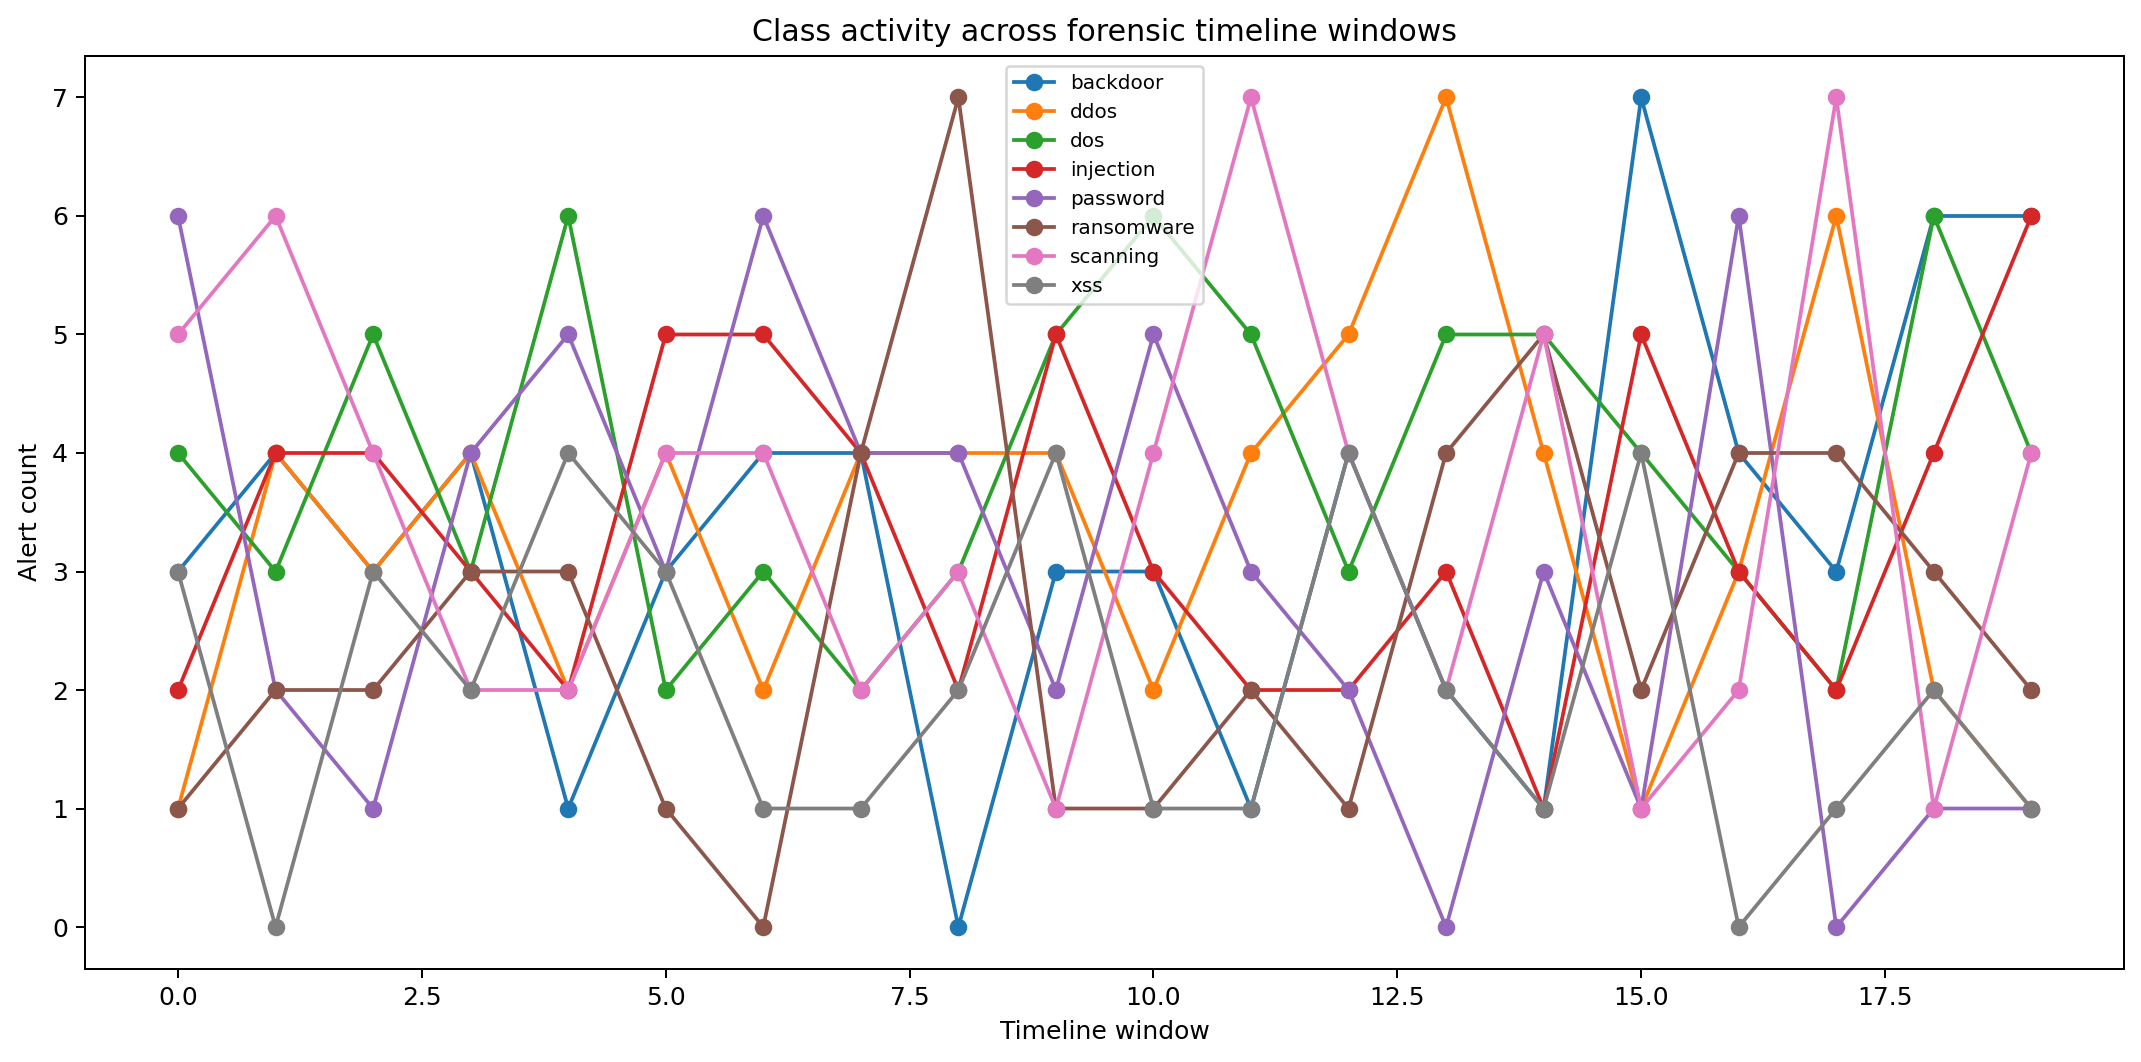

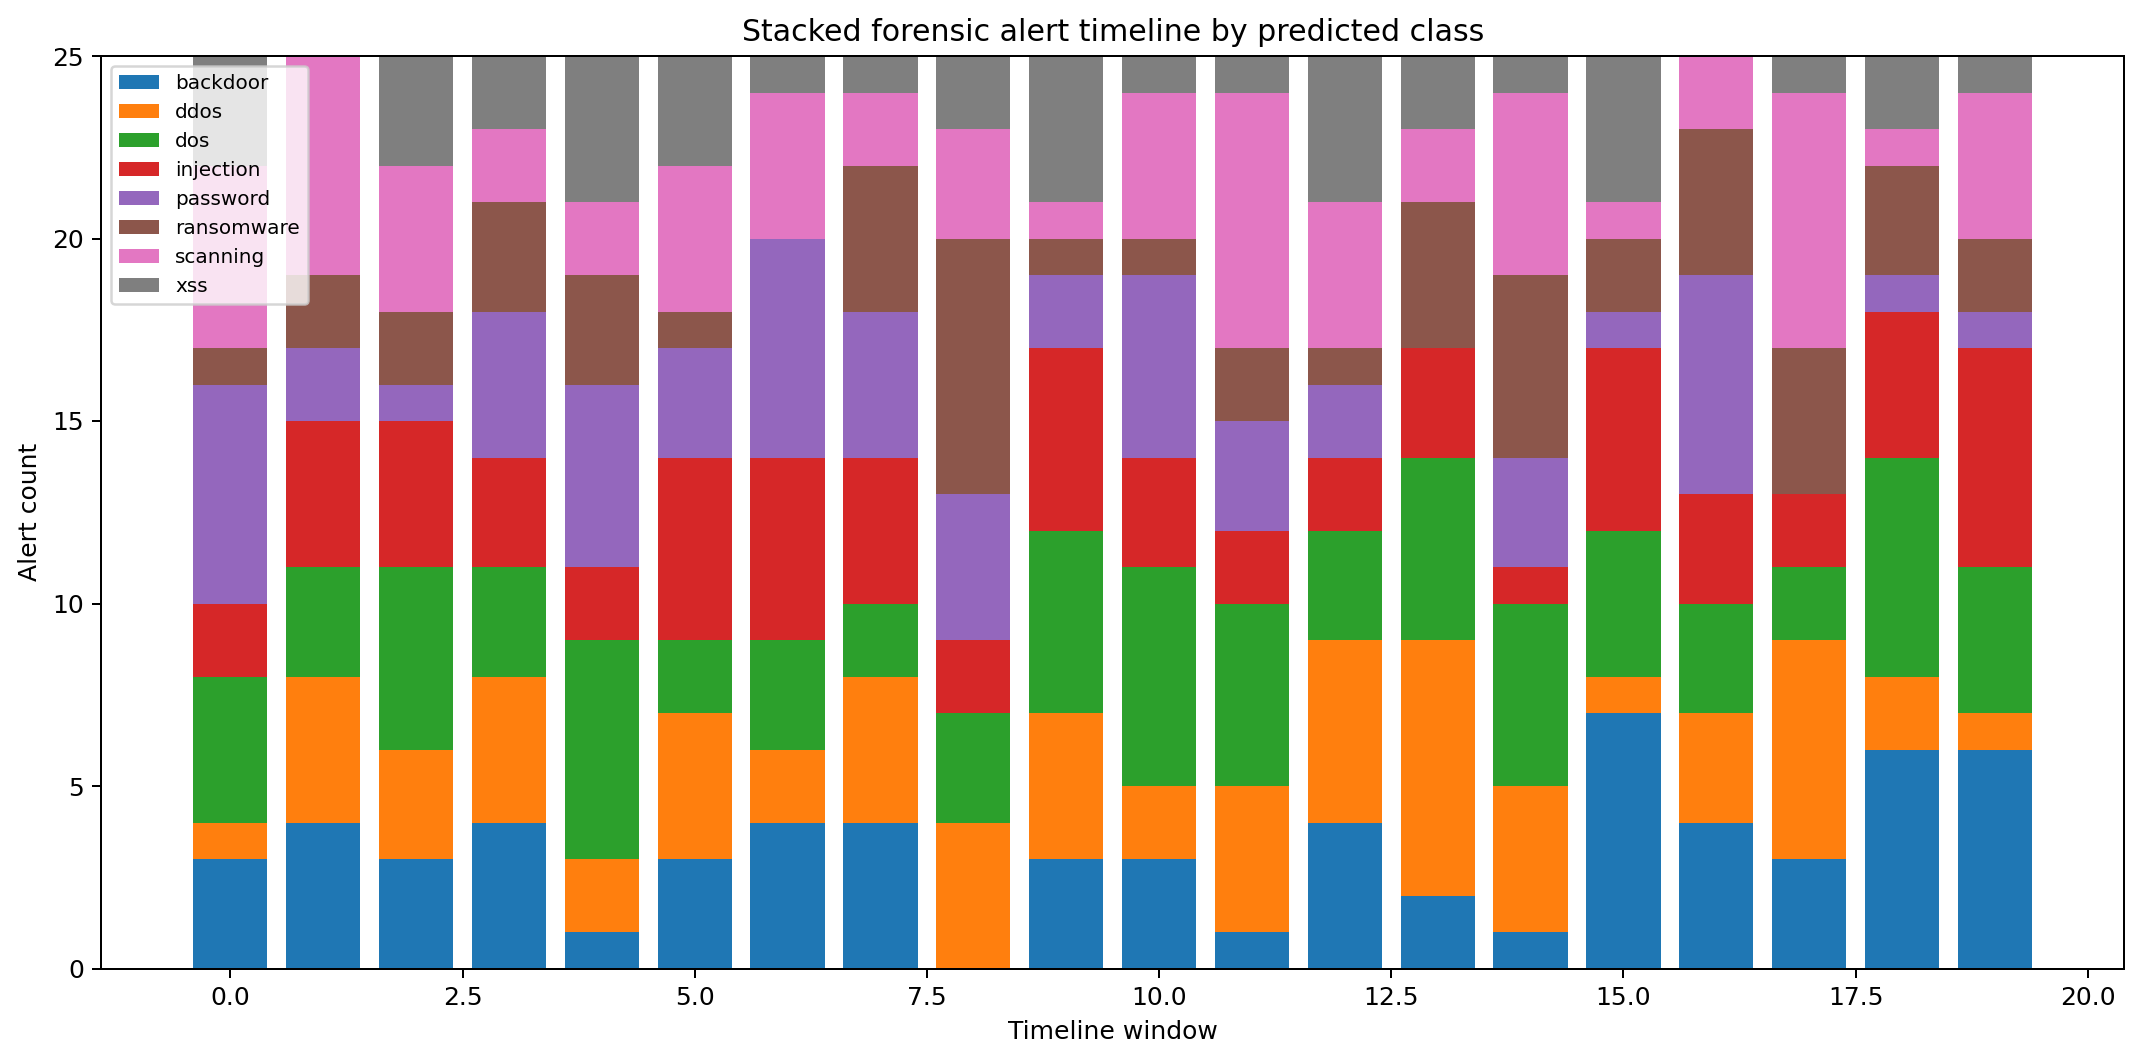

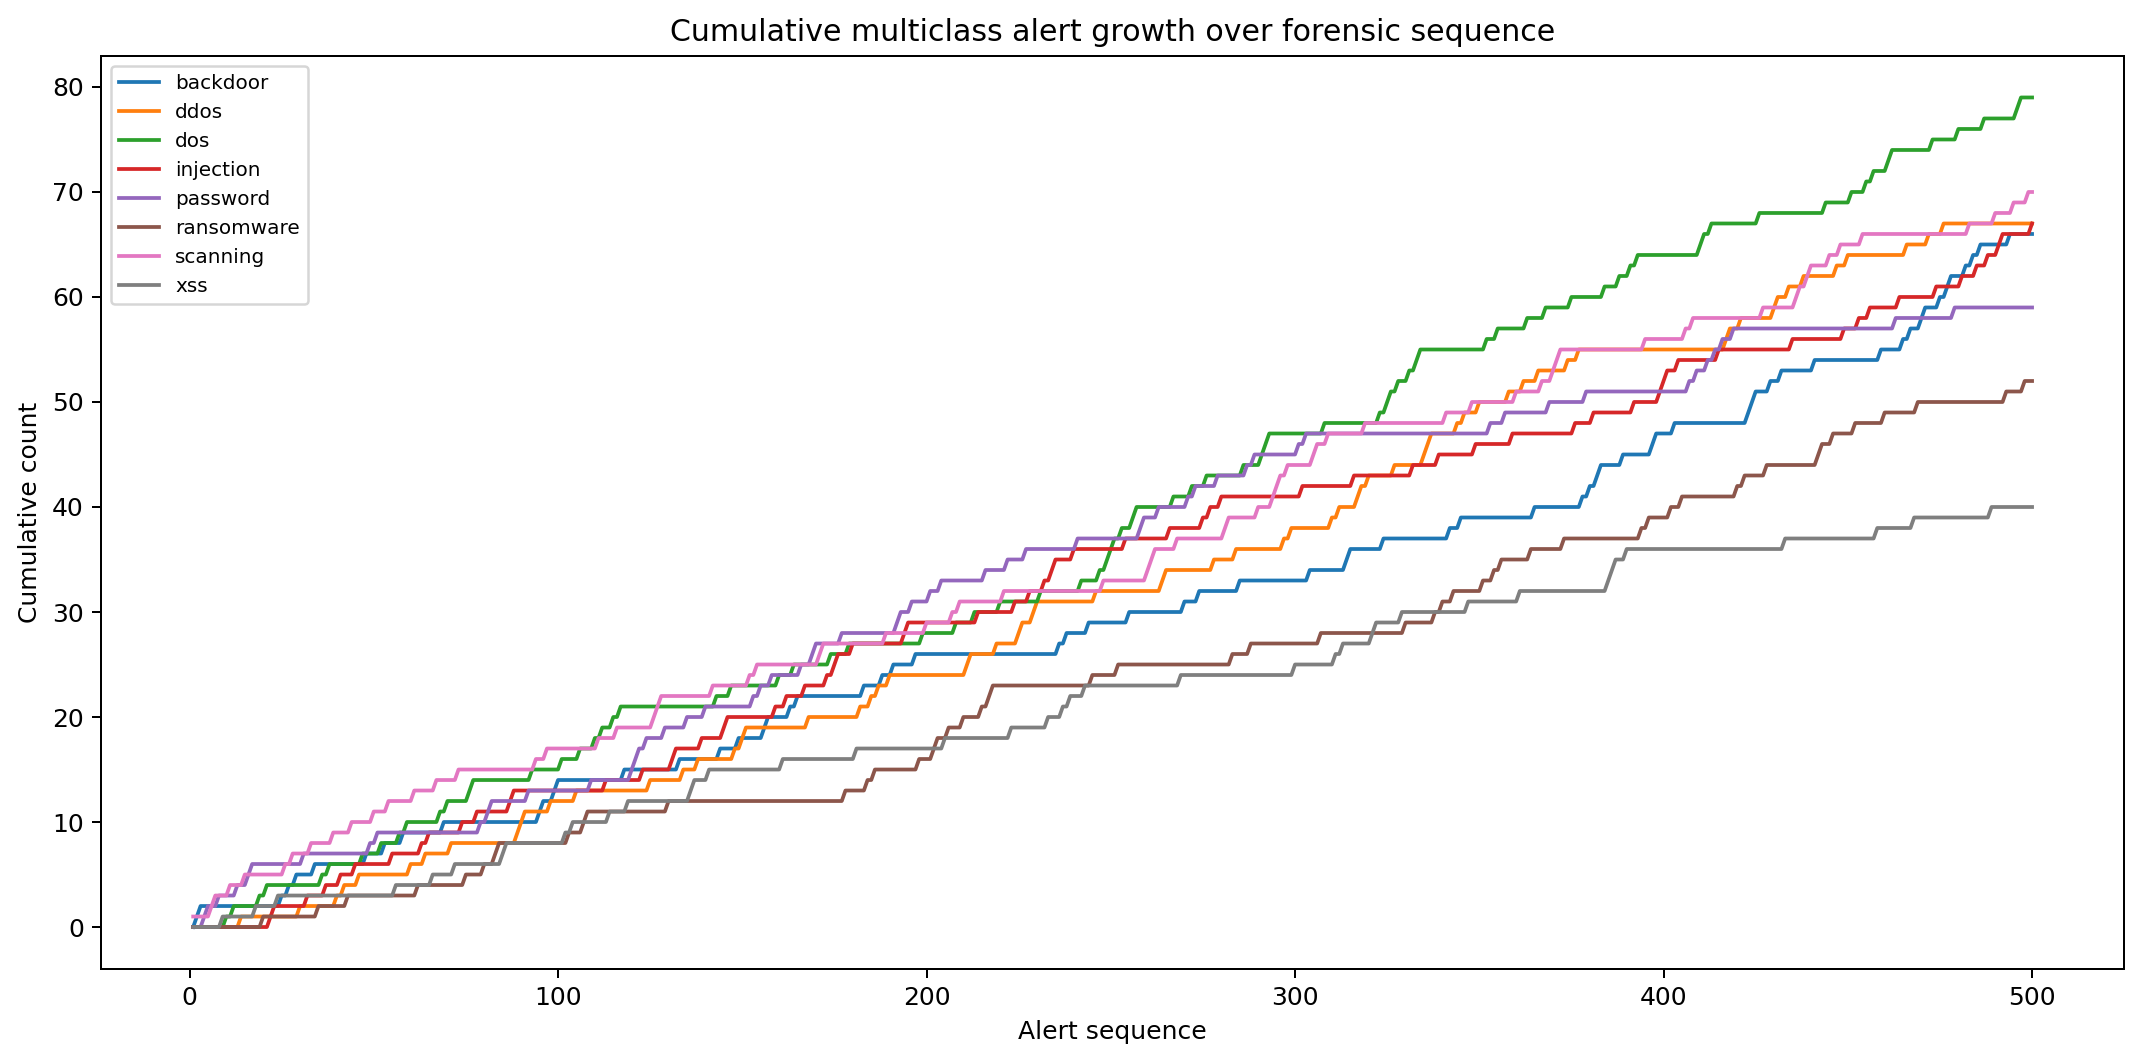


[Top class transitions]
    from_class    to_class  count
0          dos   injection     17
1     scanning    scanning     14
2          dos    scanning     14
3   ransomware         dos     12
4    injection        ddos     12
5         ddos        ddos     12
6     scanning    password     11
7     scanning         dos     11
8          dos         dos     11
9         ddos    backdoor     11
10        ddos         dos     11
11    backdoor    backdoor     11
12   injection   injection     10
13    password   injection     10
14  ransomware        ddos     10
15    backdoor         dos     10
16         dos    backdoor      9
17    password  ransomware      9
18    backdoor        ddos      9
19   injection         dos      9


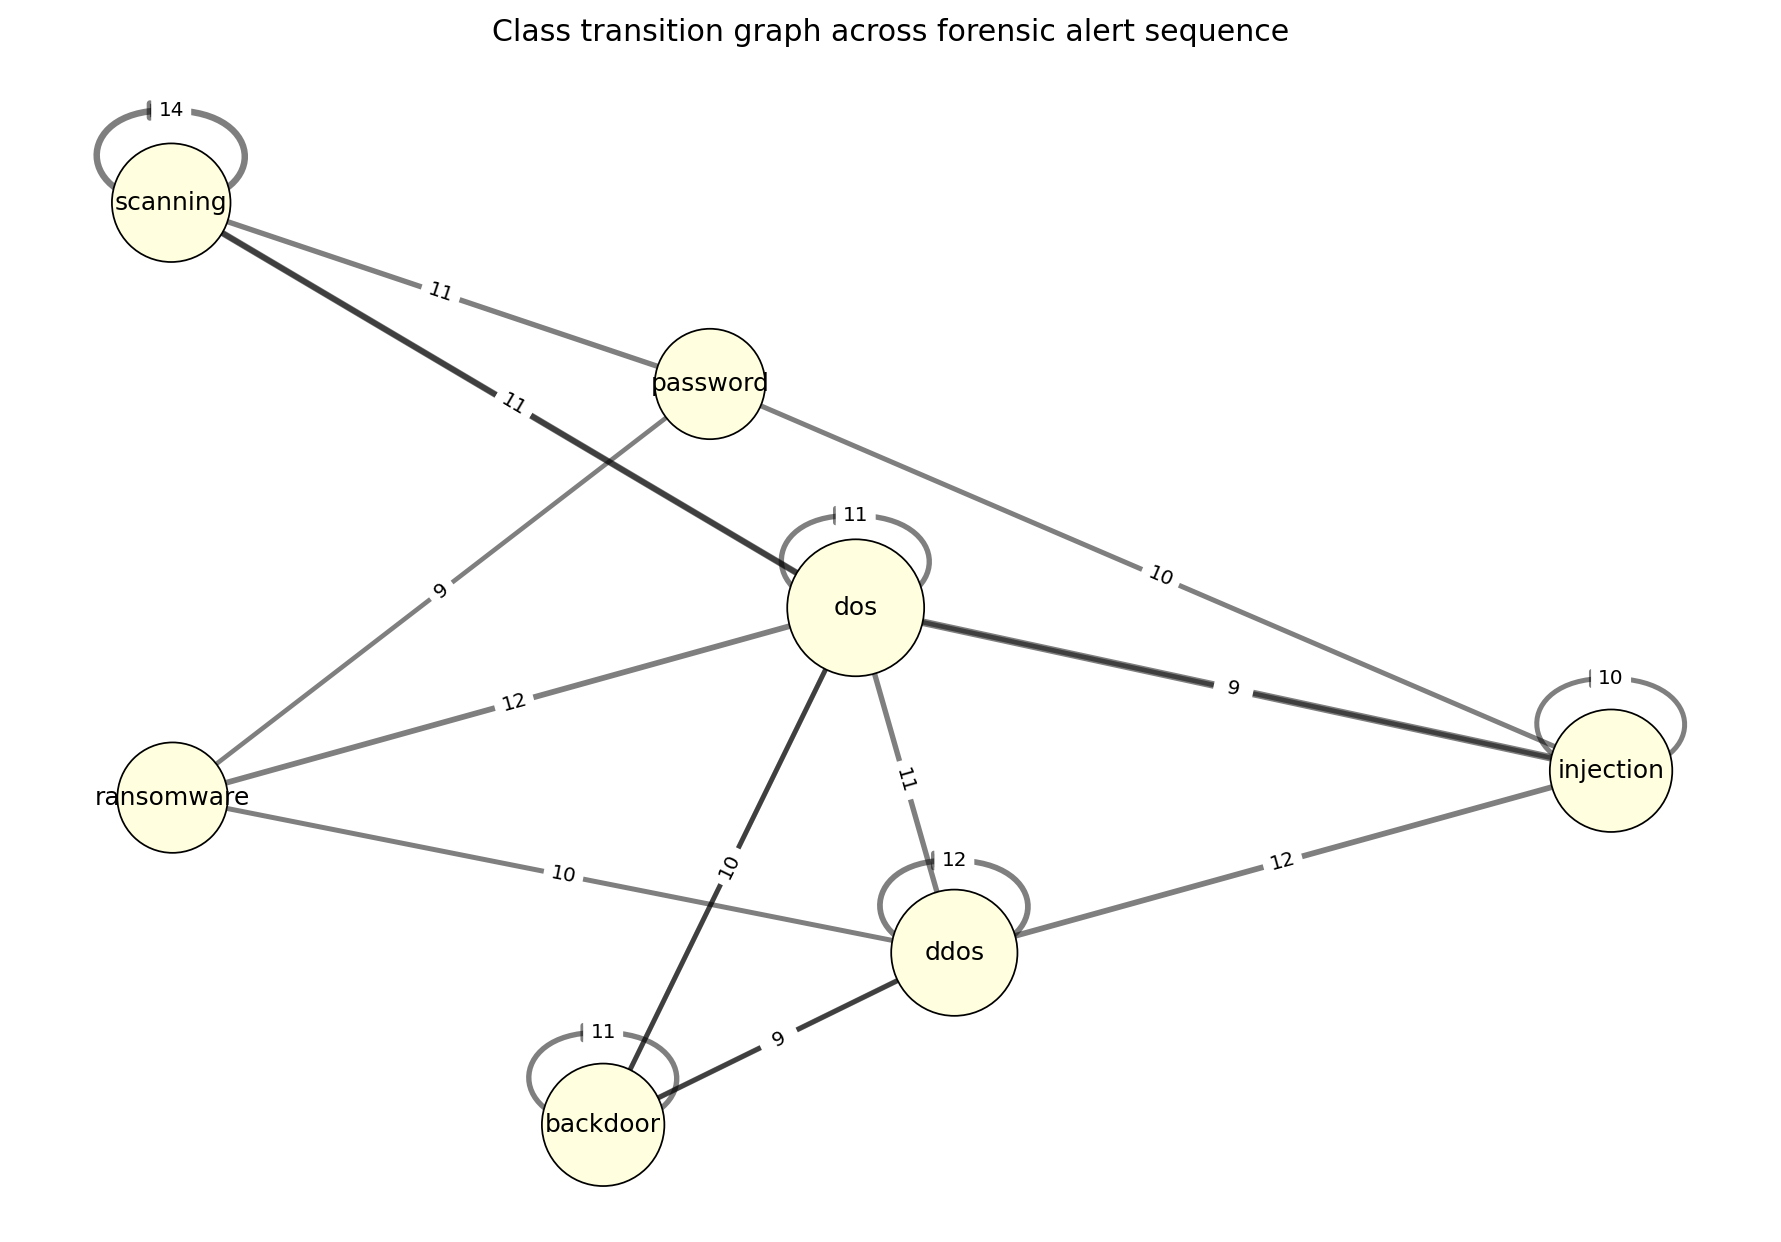


[First appearance of each class in forensic sequence]
  prediction_name  first_seen_sequence
0        scanning                    1
1        backdoor                    2
2        password                    4
3             xss                    9
4             dos                   10
5            ddos                   14
6      ransomware                   20
7       injection                   22

[Peak timeline window per class]
   class_name  peak_window  peak_count
0  ransomware            8           7
1    scanning           11           7
2        ddos           13           7
3    backdoor           15           7
4    password            0           6
5         dos            4           6
6   injection           19           6
7         xss            4           4

[Saved outputs]
Directory: multiclass_timeline_outputs
Plot files:
multiclass_timeline_outputs\CASE-20260312-195546_timeline_class_activity.png
multiclass_timeline_outputs\CASE-20260312-195546_timeline_class_

In [37]:
# ============================================================
# STEP 8: FORENSIC TIMELINE RECONSTRUCTION
# - timeline from evidence log order / created_utc
# - class activity over time
# - cumulative alert evolution
# - class transition analysis
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

print("=" * 80)
print("STEP 8: FORENSIC TIMELINE RECONSTRUCTION")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = ["EVIDENCE_LOG", "CASE_ID"]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 6A first."

assert os.path.exists(EVIDENCE_LOG), f"Evidence log not found: {EVIDENCE_LOG}"

OUT_DIR = "multiclass_timeline_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# Load evidence log
# ------------------------------------------------------------------
records = []
with open(EVIDENCE_LOG, "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        records.append(rec)

assert len(records) > 0, "Evidence log is empty."

timeline_df = pd.DataFrame(records)

print("\n[Evidence log loaded]")
print("Number of logged alerts:", len(timeline_df))
print("Columns:")
print(timeline_df.columns.tolist())

# ------------------------------------------------------------------
# Normalize timeline fields
# ------------------------------------------------------------------
timeline_df["created_utc"] = pd.to_datetime(timeline_df["created_utc"], errors="coerce", utc=True)
timeline_df["event_time"] = pd.to_datetime(timeline_df["event_time"], errors="coerce", utc=True)

# use created_utc as primary timeline field because event_time is synthetic here
timeline_df = timeline_df.sort_values(by=["created_utc", "record_id"]).reset_index(drop=True)
timeline_df["sequence_id"] = np.arange(1, len(timeline_df) + 1)

# if event_time parsed well, keep note
valid_event_time_ratio = timeline_df["event_time"].notna().mean()

print("\n[Timeline parsing status]")
print(f"Valid created_utc ratio : {timeline_df['created_utc'].notna().mean():.4f}")
print(f"Valid event_time ratio  : {valid_event_time_ratio:.4f}")

# ------------------------------------------------------------------
# Basic timeline summaries
# ------------------------------------------------------------------
timeline_summary = {
    "case_id": CASE_ID,
    "logged_alerts": int(len(timeline_df)),
    "classes_present": sorted(timeline_df["prediction_name"].dropna().unique().tolist()),
    "timeline_start_created_utc": str(timeline_df["created_utc"].min()),
    "timeline_end_created_utc": str(timeline_df["created_utc"].max()),
    "mean_confidence": float(pd.to_numeric(timeline_df["confidence"], errors="coerce").mean())
}

print("\n[Timeline summary]")
print(json.dumps(timeline_summary, indent=2))

# ------------------------------------------------------------------
# Class distribution over case sequence
# ------------------------------------------------------------------
class_counts = timeline_df["prediction_name"].value_counts().sort_values(ascending=False)
print("\n[Class counts in forensic timeline]")
print(class_counts)

# ------------------------------------------------------------------
# Bin sequence into windows for compact temporal visualization
# ------------------------------------------------------------------
N_WINDOWS = min(20, max(5, len(timeline_df) // 25))
timeline_df["window_id"] = pd.cut(
    timeline_df["sequence_id"],
    bins=N_WINDOWS,
    labels=False,
    include_lowest=True
)

window_class_counts = (
    timeline_df.groupby(["window_id", "prediction_name"])
    .size()
    .reset_index(name="count")
)

window_pivot = window_class_counts.pivot(
    index="window_id", columns="prediction_name", values="count"
).fillna(0).astype(int)

print("\n[Windowed class activity table]")
print(window_pivot)

# ------------------------------------------------------------------
# Plot 1: class activity over sequence windows
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6), dpi=180)
for cname in window_pivot.columns:
    plt.plot(window_pivot.index, window_pivot[cname], marker="o", label=cname)

plt.title("Class activity across forensic timeline windows")
plt.xlabel("Timeline window")
plt.ylabel("Alert count")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
timeline_plot1_png = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_class_activity.png")
timeline_plot1_pdf = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_class_activity.pdf")
plt.savefig(timeline_plot1_png, bbox_inches="tight")
plt.savefig(timeline_plot1_pdf, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Plot 2: stacked bar chart by class across windows
# ------------------------------------------------------------------
window_pivot_plot = window_pivot.copy()

plt.figure(figsize=(12, 6), dpi=180)
bottom = np.zeros(len(window_pivot_plot))

for cname in window_pivot_plot.columns:
    vals = window_pivot_plot[cname].values
    plt.bar(window_pivot_plot.index, vals, bottom=bottom, label=cname)
    bottom += vals

plt.title("Stacked forensic alert timeline by predicted class")
plt.xlabel("Timeline window")
plt.ylabel("Alert count")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
timeline_plot2_png = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_stacked_class_activity.png")
timeline_plot2_pdf = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_stacked_class_activity.pdf")
plt.savefig(timeline_plot2_png, bbox_inches="tight")
plt.savefig(timeline_plot2_pdf, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Plot 3: cumulative alert growth by class
# ------------------------------------------------------------------
cum_df = pd.DataFrame({"sequence_id": timeline_df["sequence_id"]})

for cname in sorted(timeline_df["prediction_name"].dropna().unique()):
    cum_df[cname] = (timeline_df["prediction_name"] == cname).astype(int).cumsum()

plt.figure(figsize=(12, 6), dpi=180)
for cname in cum_df.columns[1:]:
    plt.plot(cum_df["sequence_id"], cum_df[cname], label=cname)

plt.title("Cumulative multiclass alert growth over forensic sequence")
plt.xlabel("Alert sequence")
plt.ylabel("Cumulative count")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
timeline_plot3_png = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_cumulative_alerts.png")
timeline_plot3_pdf = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_cumulative_alerts.pdf")
plt.savefig(timeline_plot3_png, bbox_inches="tight")
plt.savefig(timeline_plot3_pdf, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Transition analysis between consecutive predicted classes
# ------------------------------------------------------------------
transitions = []
pred_seq = timeline_df["prediction_name"].tolist()

for i in range(len(pred_seq) - 1):
    transitions.append((pred_seq[i], pred_seq[i + 1]))

transition_counts = Counter(transitions)

transition_df = pd.DataFrame([
    {"from_class": a, "to_class": b, "count": c}
    for (a, b), c in transition_counts.items()
]).sort_values(by="count", ascending=False).reset_index(drop=True)

print("\n[Top class transitions]")
print(transition_df.head(20))

# ------------------------------------------------------------------
# Transition graph
# ------------------------------------------------------------------
TG = nx.DiGraph()
for _, row in transition_df.iterrows():
    TG.add_edge(row["from_class"], row["to_class"], weight=int(row["count"]))

# Keep strongest transitions for readability
TOP_TRANSITIONS = min(20, len(transition_df))
top_transition_edges = transition_df.head(TOP_TRANSITIONS)

TG_small = nx.DiGraph()
for _, row in top_transition_edges.iterrows():
    TG_small.add_edge(row["from_class"], row["to_class"], weight=int(row["count"]))

plt.figure(figsize=(10, 7), dpi=180)
pos = nx.spring_layout(TG_small, seed=42, k=1.2)

node_sizes = [1500 + 150 * TG_small.degree(n) for n in TG_small.nodes()]
edge_widths = [0.5 + 0.15 * TG_small[u][v]["weight"] for u, v in TG_small.edges()]

nx.draw_networkx_nodes(
    TG_small, pos,
    node_size=node_sizes,
    node_color="lightyellow",
    edgecolors="black",
    linewidths=0.7
)
nx.draw_networkx_edges(
    TG_small, pos,
    width=edge_widths,
    alpha=0.5,
    arrows=True,
    arrowsize=14
)
nx.draw_networkx_labels(
    TG_small, pos,
    font_size=10
)

edge_labels = {(u, v): TG_small[u][v]["weight"] for u, v in TG_small.edges()}
nx.draw_networkx_edge_labels(TG_small, pos, edge_labels=edge_labels, font_size=8)

plt.title("Class transition graph across forensic alert sequence")
plt.axis("off")
plt.tight_layout()
timeline_plot4_png = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_class_transition_graph.png")
timeline_plot4_pdf = os.path.join(OUT_DIR, f"{CASE_ID}_timeline_class_transition_graph.pdf")
plt.savefig(timeline_plot4_png, bbox_inches="tight")
plt.savefig(timeline_plot4_pdf, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Earliest appearance of each class
# ------------------------------------------------------------------
first_seen_df = (
    timeline_df.groupby("prediction_name")["sequence_id"]
    .min()
    .reset_index()
    .rename(columns={"sequence_id": "first_seen_sequence"})
    .sort_values(by="first_seen_sequence", ascending=True)
    .reset_index(drop=True)
)

print("\n[First appearance of each class in forensic sequence]")
print(first_seen_df)

# ------------------------------------------------------------------
# Peak window per class
# ------------------------------------------------------------------
peak_rows = []
for cname in window_pivot.columns:
    peak_window = int(window_pivot[cname].idxmax())
    peak_count = int(window_pivot[cname].max())
    peak_rows.append({
        "class_name": cname,
        "peak_window": peak_window,
        "peak_count": peak_count
    })

peak_window_df = pd.DataFrame(peak_rows).sort_values(by=["peak_count", "peak_window"], ascending=[False, True]).reset_index(drop=True)

print("\n[Peak timeline window per class]")
print(peak_window_df)

# ------------------------------------------------------------------
# Save tabular outputs
# ------------------------------------------------------------------
window_pivot.to_csv(os.path.join(OUT_DIR, "timeline_window_class_counts.csv"))
transition_df.to_csv(os.path.join(OUT_DIR, "timeline_class_transitions.csv"), index=False)
first_seen_df.to_csv(os.path.join(OUT_DIR, "timeline_first_seen_classes.csv"), index=False)
peak_window_df.to_csv(os.path.join(OUT_DIR, "timeline_peak_windows.csv"), index=False)
timeline_df.to_csv(os.path.join(OUT_DIR, "timeline_evidence_sequence.csv"), index=False)

step8_summary = {
    "case_id": CASE_ID,
    "logged_alerts": int(len(timeline_df)),
    "timeline_windows": int(N_WINDOWS),
    "classes_present": sorted(timeline_df["prediction_name"].dropna().unique().tolist()),
    "top_transition_edges": top_transition_edges.head(10).to_dict(orient="records"),
    "plot_files": [
        timeline_plot1_png, timeline_plot1_pdf,
        timeline_plot2_png, timeline_plot2_pdf,
        timeline_plot3_png, timeline_plot3_pdf,
        timeline_plot4_png, timeline_plot4_pdf
    ]
}

with open(os.path.join(OUT_DIR, "step8_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step8_summary, f, indent=2)

t_step8 = time.perf_counter() - t0

print("\n[Saved outputs]")
print("Directory:", OUT_DIR)
print("Plot files:")
for p in step8_summary["plot_files"]:
    print(p)

print("\n[Step 8 summary]")
print(json.dumps(step8_summary, indent=2))

print(f"\nSTEP 8 completed successfully in {t_step8:.4f} seconds.")

STEP 9: ABLATION STUDY

[Ablation scenarios]
full_features: []
remove_service_context: ['src_port', 'dst_port', 'service', 'proto']
remove_volume_features: ['src_ip_bytes', 'src_bytes', 'dst_ip_bytes', 'dst_pkts', 'src_pkts', 'dst_bytes']
remove_conn_state: ['conn_state']
remove_core_top_features: ['conn_state', 'src_ip_bytes', 'src_port', 'dst_port', 'duration', 'service']

--------------------------------------------------------------------------------
Running ablation scenario: full_features
Removed columns: None
Remaining features: 40
Numeric features  : 16
Categorical feats : 24
Validation macro-F1 : 0.989290
Test macro-F1       : 0.989058
Test accuracy       : 0.990313

--------------------------------------------------------------------------------
Running ablation scenario: remove_service_context
Removed columns: ['src_port', 'dst_port', 'service', 'proto']
Remaining features: 36
Numeric features  : 14
Categorical feats : 22
Validation macro-F1 : 0.975577
Test macro-F1       : 

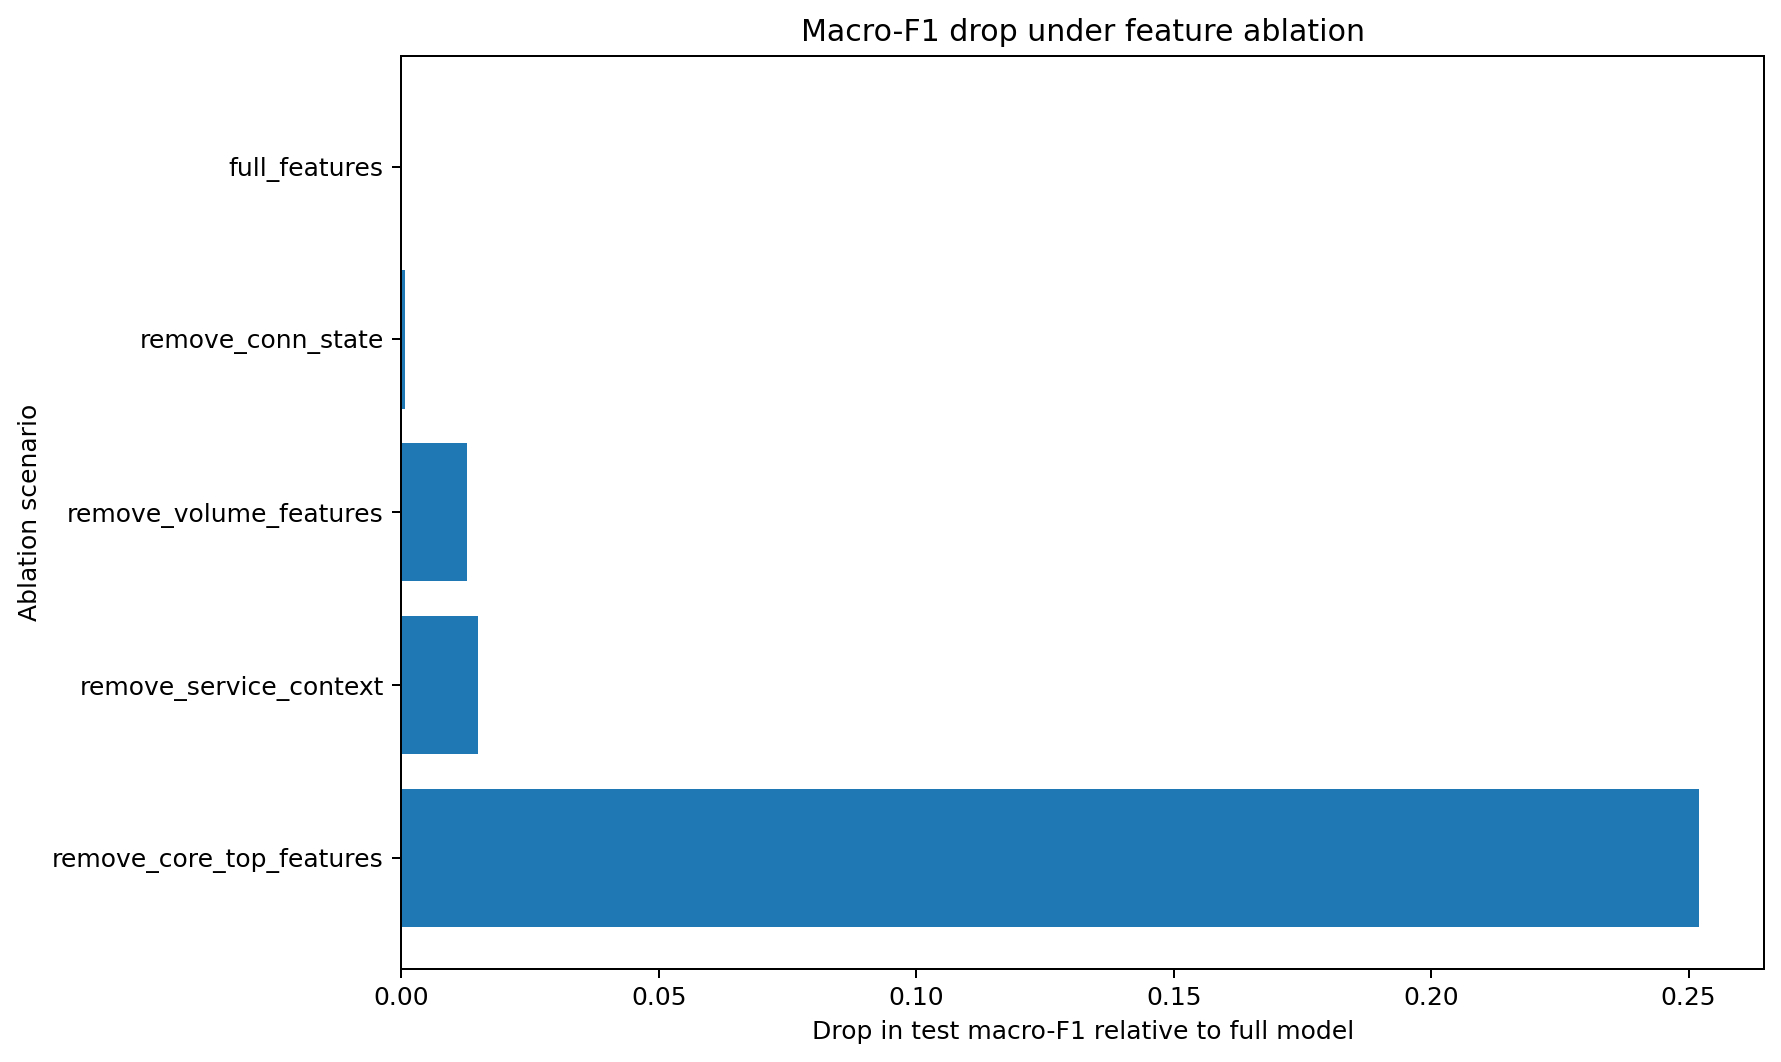


[Saved outputs]
Directory: ablation_study_outputs
Plot files:
ablation_study_outputs\ablation_macro_f1_drop.png
ablation_study_outputs\ablation_macro_f1_drop.pdf

[Step 9 summary]
{
  "full_model_test_macro_f1": 0.9890575541806188,
  "full_model_test_accuracy": 0.9903133000765434,
  "scenarios": [
    {
      "scenario": "full_features",
      "delta_test_acc": 0.0,
      "delta_test_f1_macro": 0.0
    },
    {
      "scenario": "remove_conn_state",
      "delta_test_acc": -0.0006070683875735172,
      "delta_test_f1_macro": -0.0006920517983860508
    },
    {
      "scenario": "remove_volume_features",
      "delta_test_acc": -0.011719059307942037,
      "delta_test_f1_macro": -0.012812888328942007
    },
    {
      "scenario": "remove_service_context",
      "delta_test_acc": -0.011375933697574392,
      "delta_test_f1_macro": -0.014819501117538048
    },
    {
      "scenario": "remove_core_top_features",
      "delta_test_acc": -0.20571700055427977,
      "delta_test_f1_macro": -

In [38]:
# ============================================================
# STEP 9: ABLATION STUDY
# - tests dependence on top feature groups
# - compares full model vs feature-removed variants
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

print("=" * 80)
print("STEP 9: ABLATION STUDY")
print("=" * 80)

t0 = time.perf_counter()

# ------------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------------
required_vars = [
    "X_train_raw", "X_val_raw", "X_test_raw",
    "y_train", "y_val", "y_test",
    "label_mapping", "inv_label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found."

# ------------------------------------------------------------------
# Frequency encoder
# ------------------------------------------------------------------
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps_ = {}
        self.n_features_in_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.n_features_in_ = X.shape[1]
        self.freq_maps_ = {}

        for j in range(self.n_features_in_):
            s = X.iloc[:, j].astype(str)
            vc = s.value_counts(dropna=False)
            self.freq_maps_[j] = (vc / max(len(X), 1)).to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), self.n_features_in_), dtype=float)

        for j in range(self.n_features_in_):
            fmap = self.freq_maps_.get(j, {})
            out[:, j] = X.iloc[:, j].astype(str).map(fmap).fillna(0.0).astype(float).to_numpy()

        return out

# ------------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------------
class_ids = sorted(inv_label_mapping.keys())

def evaluate_multiclass(model, X, y):
    y_pred = model.predict(X)

    res = {
        "acc": accuracy_score(y, y_pred),
        "f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, y_pred, average="weighted", zero_division=0),
        "prec_macro": precision_score(y, y_pred, average="macro", zero_division=0),
        "rec_macro": recall_score(y, y_pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro": np.nan
    }

    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X)
            res["roc_auc_ovr_macro"] = roc_auc_score(
                y, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            pass

    return res

# ------------------------------------------------------------------
# Function to build RF pipeline for a given feature subset
# ------------------------------------------------------------------
def build_rf_pipeline_for_features(X_train_subset):
    numeric_cols_local = X_train_subset.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols_local = X_train_subset.select_dtypes(exclude=[np.number]).columns.tolist()

    log_transform_candidates = [
        "duration", "src_bytes", "dst_bytes", "missed_bytes",
        "src_pkts", "src_ip_bytes", "dst_pkts", "dst_ip_bytes",
        "http_request_body_len", "http_response_body_len"
    ]
    log_num_cols = [c for c in log_transform_candidates if c in numeric_cols_local]
    plain_num_cols = [c for c in numeric_cols_local if c not in log_num_cols]

    cat_cardinality = pd.DataFrame({
        "column": categorical_cols_local,
        "n_unique": [X_train_subset[c].nunique(dropna=False) for c in categorical_cols_local]
    }).sort_values(by="n_unique", ascending=False)

    HIGH_CARD_THRESHOLD = 50
    high_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] > HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    low_mid_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] <= HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    log_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, validate=False))
    ])

    plain_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    ohe_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    freq_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("freq", FrequencyEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("log_num", log_num_pipe, log_num_cols),
            ("plain_num", plain_num_pipe, plain_num_cols),
            ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols_local),
            ("high_cat", freq_pipe, high_card_cat_cols_local),
        ],
        remainder="drop"
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ])

    feature_meta = {
        "numeric_cols": numeric_cols_local,
        "categorical_cols": categorical_cols_local,
        "log_num_cols": log_num_cols,
        "plain_num_cols": plain_num_cols,
        "high_card_cat_cols": high_card_cat_cols_local,
        "low_mid_card_cat_cols": low_mid_card_cat_cols_local
    }

    return model, feature_meta

# ------------------------------------------------------------------
# Define ablation scenarios
# ------------------------------------------------------------------
ABLATION_SCENARIOS = {
    "full_features": [],
    "remove_service_context": ["src_port", "dst_port", "service", "proto"],
    "remove_volume_features": ["src_ip_bytes", "src_bytes", "dst_ip_bytes", "dst_pkts", "src_pkts", "dst_bytes"],
    "remove_conn_state": ["conn_state"],
    "remove_core_top_features": ["conn_state", "src_ip_bytes", "src_port", "dst_port", "duration", "service"]
}

print("\n[Ablation scenarios]")
for k, v in ABLATION_SCENARIOS.items():
    print(f"{k}: {v}")

# ------------------------------------------------------------------
# Train/evaluate each scenario
# ------------------------------------------------------------------
ablation_rows = []

for scenario_name, remove_cols in ABLATION_SCENARIOS.items():
    print("\n" + "-" * 80)
    print("Running ablation scenario:", scenario_name)
    print("Removed columns:", remove_cols if remove_cols else "None")

    X_train_ab = X_train_raw.drop(columns=[c for c in remove_cols if c in X_train_raw.columns], errors="ignore").copy()
    X_val_ab   = X_val_raw.drop(columns=[c for c in remove_cols if c in X_val_raw.columns], errors="ignore").copy()
    X_test_ab  = X_test_raw.drop(columns=[c for c in remove_cols if c in X_test_raw.columns], errors="ignore").copy()

    model_ab, feature_meta = build_rf_pipeline_for_features(X_train_ab)

    print("Remaining features:", X_train_ab.shape[1])
    print("Numeric features  :", len(feature_meta["numeric_cols"]))
    print("Categorical feats :", len(feature_meta["categorical_cols"]))

    # fit on train
    t_fit0 = time.perf_counter()
    model_ab.fit(X_train_ab, y_train)
    fit_s = time.perf_counter() - t_fit0

    # validation metrics
    val_res = evaluate_multiclass(model_ab, X_val_ab, y_val)

    # refit on train+val
    X_trainval_ab = pd.concat([X_train_ab, X_val_ab], axis=0).reset_index(drop=True)
    y_trainval_ab = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)

    t_refit0 = time.perf_counter()
    model_ab.fit(X_trainval_ab, y_trainval_ab)
    refit_s = time.perf_counter() - t_refit0

    # test metrics
    t_test0 = time.perf_counter()
    test_res = evaluate_multiclass(model_ab, X_test_ab, y_test)
    test_eval_s = time.perf_counter() - t_test0

    ablation_rows.append({
        "scenario": scenario_name,
        "removed_columns": ", ".join(remove_cols) if remove_cols else "None",
        "remaining_feature_count": X_train_ab.shape[1],

        "val_acc": val_res["acc"],
        "val_f1_macro": val_res["f1_macro"],
        "val_f1_weighted": val_res["f1_weighted"],
        "val_prec_macro": val_res["prec_macro"],
        "val_rec_macro": val_res["rec_macro"],
        "val_roc_auc_ovr_macro": val_res["roc_auc_ovr_macro"],

        "test_acc": test_res["acc"],
        "test_f1_macro": test_res["f1_macro"],
        "test_f1_weighted": test_res["f1_weighted"],
        "test_prec_macro": test_res["prec_macro"],
        "test_rec_macro": test_res["rec_macro"],
        "test_roc_auc_ovr_macro": test_res["roc_auc_ovr_macro"],

        "fit_s": fit_s,
        "refit_s": refit_s,
        "test_eval_s": test_eval_s
    })

    print(f"Validation macro-F1 : {val_res['f1_macro']:.6f}")
    print(f"Test macro-F1       : {test_res['f1_macro']:.6f}")
    print(f"Test accuracy       : {test_res['acc']:.6f}")

# ------------------------------------------------------------------
# Build results table
# ------------------------------------------------------------------
ablation_df = pd.DataFrame(ablation_rows)

# compare against full model
full_row = ablation_df[ablation_df["scenario"] == "full_features"].iloc[0]

for col in ["test_acc", "test_f1_macro", "test_f1_weighted", "test_roc_auc_ovr_macro"]:
    ablation_df[f"delta_{col}"] = ablation_df[col] - full_row[col]

ablation_df = ablation_df.sort_values(by="test_f1_macro", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("[ABLATION RESULTS TABLE]")
print("=" * 80)
print(ablation_df)

# ------------------------------------------------------------------
# Compact manuscript table
# ------------------------------------------------------------------
ablation_compact_df = ablation_df[[
    "scenario",
    "removed_columns",
    "remaining_feature_count",
    "test_acc",
    "test_f1_macro",
    "test_f1_weighted",
    "test_roc_auc_ovr_macro",
    "delta_test_acc",
    "delta_test_f1_macro"
]].copy()

print("\n[Compact ablation summary]")
print(ablation_compact_df)

# ------------------------------------------------------------------
# Plot macro-F1 drop
# ------------------------------------------------------------------
plot_df = ablation_df.copy()
plot_df["f1_drop_vs_full"] = full_row["test_f1_macro"] - plot_df["test_f1_macro"]

plt.figure(figsize=(10, 6), dpi=180)
plt.barh(plot_df["scenario"][::-1], plot_df["f1_drop_vs_full"][::-1])
plt.title("Macro-F1 drop under feature ablation")
plt.xlabel("Drop in test macro-F1 relative to full model")
plt.ylabel("Ablation scenario")
plt.tight_layout()

OUT_DIR = "ablation_study_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

plot_png = os.path.join(OUT_DIR, "ablation_macro_f1_drop.png")
plot_pdf = os.path.join(OUT_DIR, "ablation_macro_f1_drop.pdf")
plt.savefig(plot_png, bbox_inches="tight")
plt.savefig(plot_pdf, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Save results
# ------------------------------------------------------------------
ablation_df.to_csv(os.path.join(OUT_DIR, "ablation_results_full.csv"), index=False)
ablation_compact_df.to_csv(os.path.join(OUT_DIR, "ablation_results_compact.csv"), index=False)

step9_summary = {
    "full_model_test_macro_f1": float(full_row["test_f1_macro"]),
    "full_model_test_accuracy": float(full_row["test_acc"]),
    "scenarios": ablation_df[["scenario", "delta_test_acc", "delta_test_f1_macro"]].to_dict(orient="records"),
    "plot_files": [plot_png, plot_pdf]
}

with open(os.path.join(OUT_DIR, "step9_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step9_summary, f, indent=2)

t_step9 = time.perf_counter() - t0

print("\n[Saved outputs]")
print("Directory:", OUT_DIR)
print("Plot files:")
print(plot_png)
print(plot_pdf)

print("\n[Step 9 summary]")
print(json.dumps(step9_summary, indent=2))

print(f"\nSTEP 9 completed successfully in {t_step9:.4f} seconds.")

In [39]:
# ============================================================
# SYSTEM / EXPERIMENTAL ENVIRONMENT INFORMATION
# ============================================================

import platform
import sys
import os
import psutil
import multiprocessing
import subprocess

print("="*70)
print("SYSTEM INFORMATION")
print("="*70)

print("Operating System:", platform.system(), platform.release())
print("OS Version:", platform.version())
print("Machine Architecture:", platform.machine())
print("Processor:", platform.processor())

print("\nCPU INFORMATION")
print("Physical cores:", psutil.cpu_count(logical=False))
print("Logical cores:", psutil.cpu_count(logical=True))
print("CPU Frequency:", psutil.cpu_freq())

print("\nMEMORY INFORMATION")
ram = psutil.virtual_memory()
print("Total RAM (GB):", round(ram.total / (1024**3), 2))
print("Available RAM (GB):", round(ram.available / (1024**3), 2))

print("\nPYTHON ENVIRONMENT")
print("Python Version:", sys.version)
print("Python Executable:", sys.executable)

print("\nKEY LIBRARY VERSIONS")

import numpy
import pandas
import sklearn
import matplotlib
import networkx

print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("NetworkX:", networkx.__version__)

try:
    import shap
    print("SHAP:", shap.__version__)
except:
    print("SHAP: not installed")

try:
    import lime
    print("LIME:", lime.__version__)
except:
    print("LIME: not installed")

try:
    import tensorflow
    print("TensorFlow:", tensorflow.__version__)
except:
    print("TensorFlow: not installed")

print("\nGPU INFORMATION")

try:
    import torch
    if torch.cuda.is_available():
        print("CUDA Available:", torch.cuda.get_device_name(0))
    else:
        print("CUDA not available")
except:
    print("PyTorch not installed (GPU check skipped)")

print("\nENVIRONMENT PATH")
print(os.getcwd())

print("="*70)

SYSTEM INFORMATION
Operating System: Windows 10
OS Version: 10.0.26200
Machine Architecture: AMD64
Processor: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel

CPU INFORMATION
Physical cores: 16
Logical cores: 24
CPU Frequency: scpufreq(current=1453.0, min=0.0, max=2100.0)

MEMORY INFORMATION
Total RAM (GB): 63.69
Available RAM (GB): 34.52

PYTHON ENVIRONMENT
Python Version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:36:49) [MSC v.1944 64 bit (AMD64)]
Python Executable: C:\Users\amala\anaconda3\envs\mbzuai\python.exe

KEY LIBRARY VERSIONS
NumPy: 2.2.6
Pandas: 2.3.3
Scikit-learn: 1.7.2
Matplotlib: 3.10.8
NetworkX: 3.4.2
SHAP: 0.48.0
LIME: not installed
TensorFlow: not installed

GPU INFORMATION
PyTorch not installed (GPU check skipped)

ENVIRONMENT PATH
F:\MBZUAI UAE\FIRST WORK\March\ton-iot
